# Subsample JEPA

## Two independent seeds

`jepa_constant_aug_v1` keys the augmentation on the run seed, so each model
init also gets its own coefficient trajectory — confounding variation from
initialisation with variation from *which* functions were sampled. Here:

| seed | controls |
|---|---|
| `MODEL_SEED` | init, dropout, optimiser, DataLoader shuffle |
| `DATA_SEED` | coefficients, point clouds, augmentation retries |

Shuffle stays on `MODEL_SEED` — it is which examples share a batch, i.e.
optimisation randomness, not a property of the data.

The augmentation key becomes `(DATA_SEED, stage, epoch, idx, stream, attempt)`.


## 0. Colab / environment setup

The repository is checked out on Drive (that is also where `data/synthetic.pkl`
lives — it is 194 MB and not tracked by Git). Checkpoints are **not** written
there: see section 6.

If library code changes while this runtime is live, restart the kernel before
relying on the new imports.

In [ ]:
import datetime
import os
import shutil
import subprocess
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

# Edit these two if your Drive layout differs.
# Repository used to run the experiments in this notebook.
#
# NOTE FOR SYMBA USERS:
# This notebook was developed against the standalone symbolic-jepa repository.
# If running the version merged into ML4SCI/SYMBA, change REPO_URL and REPO_DIR
# below to point to the corresponding SYMBA checkout/project directory.
#
# The training code itself is contained in this contribution under
# SYMBA_REG/SymbolicJEPA_David_ZiPeng_Zhou/.
DRIVE_BASE = Path('/content/drive/MyDrive/Symba')
REPO_URL = 'https://github.com/zzpDavid2/symbolic-jepa.git'

# Running a notebook on Drive dirties the tracked .ipynb, blocking
# `git pull --ff-only`. True discards tracked-file changes before pulling.
DISCARD_LOCAL_REPO_CHANGES = False


def sh(cmd: str) -> int:
    """Run a shell command and echo it. Returns the exit code."""
    print(f'$ {cmd}')
    code = os.system(cmd)
    if code != 0:
        print(f'  -> exit {code}')
    return code

def sync_repo(repo_dir, discard: bool = False) -> bool:
    # Fast-forward the checkout, and say precisely why if it cannot.
    #
    # `git pull --ff-only` refuses on two distinct blockers, and `sh` only
    # prints the exit code -- so without this the pull silently no-ops, the
    # runtime keeps OLD library code, and the symptom surfaces many cells later
    # as an ImportError for a symbol that is definitely on origin.
    #
    #  * dirty TRACKED files: running a notebook on Drive writes outputs into
    #    the tracked .ipynb, so the checkout is dirty after the very first run;
    #  * UNTRACKED files the incoming commits also contain: a file copied into
    #    the checkout by hand and later committed upstream. git will not
    #    clobber it, and meanwhile Python keeps importing that stale copy.
    #
    # With `discard`, tracked files are reverted and untracked collisions are
    # MOVED to a timestamped backup beside the repo -- never deleted, because a
    # hand-placed file is exactly the kind that might hold unique work.
    repo_dir = Path(repo_dir)

    def git(*args):
        return subprocess.run(['git', '-C', str(repo_dir), *args],
                              capture_output=True, text=True)

    git('fetch', '--quiet', 'origin')
    branch = git('rev-parse', '--abbrev-ref', 'HEAD').stdout.strip() or 'main'
    incoming = set(git('diff', '--name-only',
                       f'HEAD..origin/{branch}').stdout.split())
    untracked = set(git('ls-files', '--others', '--exclude-standard')
                    .stdout.split())
    dirty = set(git('diff', '--name-only').stdout.split())

    collisions = sorted(incoming & untracked)
    blocked = sorted(incoming & dirty)

    if (collisions or blocked) and discard:
        stamp = datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
        backup = repo_dir.parent / f'repo_untracked_backup_{stamp}'
        for rel in collisions:
            dest = backup / rel
            dest.parent.mkdir(parents=True, exist_ok=True)
            shutil.move(str(repo_dir / rel), str(dest))
        if collisions:
            print(f'[repo] moved {len(collisions)} untracked file(s) aside '
                  f'-> {backup}')
        if blocked:
            git('checkout', '--', *blocked)
            print(f'[repo] reverted {len(blocked)} tracked file(s)')
        collisions, blocked = [], []

    result = git('pull', '--ff-only')
    print((result.stdout + result.stderr).strip())

    if result.returncode != 0:
        print('\n' + '!' * 72)
        print('[repo] PULL FAILED -- this runtime is on OLD library code.')
        if collisions:
            print('\nUntracked files that the incoming commits also contain:')
            for rel in collisions:
                print(f'  {rel}')
        if blocked:
            print('\nModified tracked files blocking a fast-forward:')
            for rel in blocked:
                print(f'  {rel}')
        print('\n  -> set DISCARD_LOCAL_REPO_CHANGES = True above and re-run '
              'this cell.\n     Untracked files are moved aside, not deleted.')
        print('!' * 72 + '\n')
        return False

    # Drive mtimes are unreliable, and a .pyc that merely looks newer than a
    # freshly pulled .py would shadow it.
    subprocess.run(f'find "{repo_dir}" -name __pycache__ -type d '
                   f'-exec rm -rf {{}} +', shell=True, capture_output=True)
    return True


DRIVE_MOUNTED = False
if IN_COLAB:
    from google.colab import drive

    try:
        drive.mount('/content/drive')
        DRIVE_MOUNTED = True
    except Exception as e:
        # Drive is a durable-backup convenience, not a training requirement.
        print(f'[backup WARNING] Drive mount failed: {type(e).__name__}: {e}')
        print('Training can still run; checkpoints stay on /content only.')

    REPO_DIR = DRIVE_BASE / 'symbolic-jepa'
    if not REPO_DIR.exists():
        REPO_DIR.parent.mkdir(parents=True, exist_ok=True)
        sh(f'git clone {REPO_URL} "{REPO_DIR}"')
    else:
        sync_repo(REPO_DIR, discard=DISCARD_LOCAL_REPO_CHANGES)

    # Never blanket-install sympy: Colab preinstalls it, and pip replacing it
    # under a live kernel leaves the imported module stale. torch imports
    # `torch.utils._sympy.functions` LAZILY, so that surfaces mid-training as
    # `module 'sympy' has no attribute 'core'`. Install only what is missing.
    _missing = []
    for _mod in ('sympy', 'scipy'):
        try:
            __import__(_mod)
        except ImportError:
            _missing.append(_mod)
    if _missing:
        sh(f'{sys.executable} -m pip install -q {" ".join(_missing)}')
        print(f'\n[SETUP] installed {_missing} — RESTART THE RUNTIME NOW '
              f'(Runtime > Restart session), then re-run. Continuing in this '
              f'kernel will fail later inside training.')
    else:
        print('sympy / scipy already present — not reinstalling')
else:
    REPO_DIR = Path.cwd()

os.chdir(REPO_DIR)
sys.path.insert(0, str(REPO_DIR))

import importlib  # noqa: E402

import symbolic_jepa  # noqa: E402

# Two faults produce the same ImportError many cells later: a pull that never
# landed (old .py on disk), or a stale import in this kernel. They need
# different fixes, so name which one it is.
_REQUIRED = {
    'symbolic_jepa.templates': (
        'AUGMENTATION_VERSION', 'templates_fingerprint',
        'DynamicConstantMultiViewDataset', 'build_multiview_template_splits',
        'stage2_fingerprint'),
    'symbolic_jepa.jepa': ('subsample_consistency_loss',),
    'symbolic_jepa.agreement': ('compare_runs', 'load_run_matrix',
                                'paired_seed_report'),
}
for _mod_name, _names in _REQUIRED.items():
    try:
        _mod = importlib.import_module(_mod_name)
    except ImportError as _e:
        raise ImportError(
            f'{_mod_name} is missing entirely ({_e}). The checkout is behind '
            f'origin — see the pull warning above.') from _e
    _absent = [n for n in _names if not hasattr(_mod, n)]
    if _absent:
        _src = Path(_mod.__file__).read_text()
        if all(n in _src for n in _absent):
            raise ImportError(
                f'{_mod_name} is missing {_absent}, but {_mod.__file__} DOES '
                f'contain them — this kernel is holding a stale import.\n'
                f'  -> Runtime > Restart session, then Run all.')
        raise ImportError(
            f'{_mod_name} is missing {_absent}, and {_mod.__file__} does not '
            f'contain them — the checkout is behind origin.\n'
            f'  -> see the pull warning above; set '
            f'DISCARD_LOCAL_REPO_CHANGES = True if local edits block the pull.')
print('library check: OK — templates + agreement are current')

print(f'\nEnvironment : {"Colab" if IN_COLAB else "local"}')
print(f'Repo        : {REPO_DIR}')
print(f'symbolic_jepa imported from: {symbolic_jepa.__file__}')
sh(f'git -C "{REPO_DIR}" rev-parse --short HEAD')

Mounted at /content/drive
Already up to date.
sympy / scipy already present — not reinstalling
library check: OK — templates + agreement are current

Environment : Colab
Repo        : /content/drive/MyDrive/Symba/symbolic-jepa
symbolic_jepa imported from: /content/drive/MyDrive/Symba/symbolic-jepa/symbolic_jepa/__init__.py
$ git -C "/content/drive/MyDrive/Symba/symbolic-jepa" rev-parse --short HEAD


0

## 1. Imports and global config

Every experiment-defining constant lives in this one cell. `make_run_config`
(section 6) serialises them into each checkpoint, so a checkpoint written
under different settings cannot be reused.

In [ ]:
import datetime
import gc
import hashlib
import json
import random
import time

import numpy as np
import torch
# Eager on purpose: torch defers `torch.utils._sympy.functions` until deep in
# training, so a version mismatch would detonate mid-run instead of at setup.
import sympy.core                     # noqa: F401
import torch.utils._sympy.functions   # noqa: F401
from torch.utils.data import DataLoader, Subset
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import tqdm

from symbolic_jepa import (
    PrefixTokenizer,
    TNet, SymbolicTransformer,
    JEPAPredictor, IdentityPredictor, jepa_loss,
    subsample_consistency_loss,
    teacher_forced_counts,
    evaluate_predictions,
    sym_spread, pred_spread, retrieval_top1, common_mode,
)
from symbolic_jepa.datacache import DataCache, cached_prefix_tree
from symbolic_jepa.templates import (
    AUGMENTATION_VERSION, ConstantSampler, build_multiview_template_splits,
    load_template_dataset, templates_fingerprint, stage2_fingerprint,
    canonical_split_report, describe_realizations, audit_constant_sampling,
)
from symbolic_jepa.agreement import (
    compare_runs, load_run_matrix, paired_seed_report,
)
from symbolic_jepa.checkpointing import (
    CheckpointError,
    validate_checkpoint, save_checkpoint_atomic, save_json_atomic,
    load_local_or_restore,
    backup_checkpoint_to_drive, check_best_latest_consistency,
    write_manifest, sync_local_runs_to_drive,
)
from symbolic_jepa.tokenizer import prefix_to_sympy

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


In [ ]:
# ── Experiment identity ────────────────────────────────────────────────
# Stamped into every run_config. A v1 checkpoint carries no such field and a
# future v3 carries a different one, so neither can validate as a v2 run.
#
# vocab40: the tokenizer gained three/four/neg2/neg3/neg4, so every exponent
# is now a structural token instead of collapsing to 'C'. Vocabulary went
# 27 -> 32 at MAX_VARS=1, which changes the embedding and output-projection
# shapes — no earlier checkpoint can be loaded, and earlier metrics.json
# files describe a different token space. Kept distinct so the pre-vocab40
# results stay intact and comparable.
#
# _matched: Stage 2 now tears down and rebuilds its training DataLoader so
# every pretraining condition enters fine-tuning with the same worker RNG
# state. persistent_workers keeps one worker set alive for the whole run and
# seed_worker only fires at worker creation, so a 10-epoch Stage 1 previously
# left its workers 10 epochs of point-cloud draws ahead of the pretrain_0
# baseline — confounding the very comparison this experiment makes. The
# Stage-2 data trajectory therefore differs from earlier vocab40 runs and the
# two cannot be pooled. Representation diagnostics also moved to a fixed
# 256-example validation subset (weights unaffected).
#
# constant_aug_v1: the training set resamples coefficients per __getitem__.
# Depth, width and vocabulary are identical to jepa_pretrain_v2_l8, so its
# checkpoints would LOAD here without complaint — only a distinct
# EXPERIMENT_VERSION keeps one from being resumed into this run, and run_config
# additionally carries every constant-sampling setting.
EXPERIMENT_VERSION = 'subsample_jepa_constant_aug_v1'

# Recorded in every run_config. The previous experiment used the coupled policy
# (augmentation keyed on the run seed); a checkpoint from it must never be
# resumed here even though the weights are shape-compatible, and this field
# makes that a structural impossibility rather than a naming convention.
AUGMENTATION_SEED_POLICY = 'independent_data_seed'

# Bump when DECODING or SCORING changes, independently of training. Trained
# checkpoints stay valid; only metrics.json is invalidated, so affected runs
# are re-scored rather than retrained.
#
# v3: evaluation dropped sp.Expr.equals() from the equivalence cascade (it
# hung unboundedly) and fixed the constant-permutation subs to be
# simultaneous, which makes algebraic_equiv strictly more permissive than
# the scores cached under v2_strict_eos.
EVAL_VERSION = 'v3_expanded_numerics'

# ── Model / optimisation (identical to jepa_pretrain_v2_l8) ────────────
MAX_VARS = 1                  # univariate synthetic data
D_INPUT = MAX_VARS + 1        # (x, y) = 2
N_POINTS = 1000
MAX_SEQ = 64
D_MODEL = 512
N_HEADS = 8
N_LAYERS = 8                  # matches jepa_pretrain_v2_l8, the baseline here
DROPOUT = 0.2

LR = 3e-4
WEIGHT_DECAY = 0.1
BATCH = 16
VAL_EVERY = 1
USE_AMP = True

# ── The comparison ─────────────────────────────────────────────────────
FINETUNE_EPOCHS = 30
PRETRAIN_EPOCHS_VALUES = [0, 20]

# Three model seeds first; widen to the full eight if the result is promising.
MODEL_SEEDS = [3095, 4003, 492]

# Data-side randomness: coefficients, point clouds, augmentation retries.
# ONE precommitted data seed to start. The list is here so a follow-up can add
# [2026, 31415, 271828] and test whether any effect survives a change of
# augmentation trajectory — but that is a separate, later decision, and running
# it now would turn a clean 16-run experiment into an underpowered 48-run one.
DATA_SEEDS = [2026]

# Alias so the plotting / inspection cells below keep reading naturally. The
# unit of replication in this experiment is the MODEL seed.
SEEDS = MODEL_SEEDS
GLOBAL_SEED = SEEDS[0]        # notebook-level RNG; per-run seeds come from SEEDS

# ── Subsample-JEPA objective (Stage 1) ─────────────────────────────────
N_VIEWS = 2                   # subsamples per item per step
POOL_MULT = 4                 # pool is N_POINTS*POOL_MULT before subsampling
VIEW_POINTS = None            # points per view (None = N_POINTS)

# 'centered' subtracts each view's batch mean before the cosine. Raw cosine
# between two views of the same function starts ~0.99, giving almost no
# gradient, and is minimised by total collapse; the centered form penalises it.
SUBSAMPLE_LOSS = 'centered'   # 'centered' (recommended) | 'cosine'
SUBSAMPLE_LOSS_OTHER = 'cosine' if SUBSAMPLE_LOSS == 'centered' else 'centered'

# ── Symbolic-JEPA settings, kept for Stage-2 validation logging ────────
JEPA_LOSS = 'cosine'          # 'cosine' (ordinary) | 'centered'
JEPA_PREDICTOR = 'identity'   # 'identity' | 'mlp'
PRETRAIN_STOPGRAD = True      # see the note below — False collapses Stage 1

# ── Data ───────────────────────────────────────────────────────────────
# Canonical forms come from data/synthetic_templates.pkl, built once by
#   python tools/build_template_dataset.py --max-expressions 200000 --max-vars 1
# Same strings, filters and order as MAX_SYNTH selects, so the split matches.
TEMPLATE_PKL = str(REPO_DIR / 'data' / 'synthetic_templates.pkl')
SYNTH_PKL = str(REPO_DIR / 'data' / 'synthetic.pkl')   # source of the above
SYNTH_SEED = 42
MAX_SYNTH = 200_000           # raw strings the template file was built from
DEDUPE_BY_TOKENS = True       # one template per distinct token sequence
USE_DATA_CACHE = True         # reuse the branch tree
GROUP_BY_TOKENS = True        # no canonical form spans two splits

# ── Dynamic constant augmentation ──────────────────────────────────────
# The swept feature. False is a same-notebook control; the real baseline is
# jepa_pretrain_v2_l8, whose data path is untouched.
DYNAMIC_CONSTANTS = True

# 'global': every coefficient draws its MAGNITUDE from one shared pool, fitted
# on training forms only, so a form's coefficients cannot identify it — the
# shortcut this augmentation exists to remove. SIGN comes from the reference
# because sign is structural (exp(c*(x-mu)**2) diverges at c > 0): free signs
# measured 0.749 accept with 4.2% of forms starved, vs 0.980 and 0.0%.
# 'empirical' = per-form pools (the form-biased ablation); 'perturb' = no pools.
CONSTANT_MODE = 'global'
CONSTANT_LOG_SPREAD = 2.0     # 'perturb' spread, and the per-slot fallback
CONSTANT_JITTER = 1.0         # >1 makes pooled draws continuous, not a grid

# None draws from the global NumPy RNG, exactly how the existing point-cloud
# augmentation is seeded (per worker, by seed_worker). An int instead pins
# coefficients to (seed, epoch, idx) — but then the train loader MUST be built
# with persistent_workers=False, or forked workers never see the epoch update.
# Every realisation is a pure function of (seed, stage, epoch, idx), so worker
# count, scheduling, restart and resume cannot change what an example sees.
# False = legacy global-RNG stream, reproducible only for an uninterrupted run.
DETERMINISTIC_AUGMENTATION = True

# The base seed is the DATA seed, assigned in train_one. Every model seed
# therefore trains on the identical augmented trajectory, which is the whole
# point of this notebook. This placeholder puts the dataset in deterministic
# mode and makes the section-4 diagnostics representative of DATA_SEEDS[0].
CONSTANT_SEED = DATA_SEEDS[0] if DETERMINISTIC_AUGMENTATION else None

# Redraws before falling back to reference coefficients. Rejection catches a
# near-zero coefficient erasing a branch, and blow-ups past CONSTANT_MAX_ABS.
CONSTANT_MAX_TRIES = 8
CONSTANT_MAX_ABS = 1e6

# ── DataLoader ─────────────────────────────────────────────────────────
# Workers fork from identical NumPy/Python RNG state and would emit identical
# augmented clouds; `seed_worker` (section 2) fixes that. Set to 0 to move
# sampling back into the main process — that also makes Stage 2's augmentation
# stream reset per epoch, so pre0 and pre10 see bit-identical clouds (see the
# trajectory note in section 2).
NUM_WORKERS = 2

# ── Evaluation ─────────────────────────────────────────────────────────
MAX_EVAL_EXAMPLES = 0         # 0 = full test set; a positive N caps greedy decode

# Symbolic metrics DURING training, so the advantage reads as a curve rather
# than one end-of-run number. Costs SYMBOLIC_EVAL_N greedy decodes plus a BFGS
# fit each, every SYMBOLIC_EVAL_EVERY epochs. Set 0 to disable.
SYMBOLIC_EVAL_EVERY = 5       # epochs between mid-training symbolic evals
SYMBOLIC_EVAL_N = 128         # validation examples per mid-training eval

# ── Drive backup cadence ───────────────────────────────────────────────
DRIVE_BACKUP_EVERY = 5        # epochs between latest.pt backups

### Why `PRETRAIN_STOPGRAD` must stay `True`

Stage 1 optimises the JEPA loss alone. With gradients reaching both sides
(`encoder` and `tok_embed`/`pos_embed`/`transformer`/`norm`, with `head.weight`
tied to `tok_embed.weight`), the pair is free to converge on one constant
vector: `cos = 1`, loss = 0, nothing learned. Measured over 6 JEPA-only epochs
(d_model=128, 458 equations), `stopgrad=False` drove JEPA loss 1.028 → 0.0037
while `std(z_sym)` fell 0.716 → 0.078 and off-diagonal `cos(z_sym)` rose
0.473 → 0.994 — the full collapse signature.

With the stop-gradient, Stage 1 trains **only the T-Net encoder** against a
fixed, randomly-initialised symbolic target. The decoder is not pretrained,
so this measures *"does JEPA-pretraining the point-cloud encoder help?"*, not
*"does pretraining the whole model help?"*

`torch.no_grad()` alone is **not** sufficient — it blocks gradients but leaves
dropout active, so the "fixed" target would be re-sampled every step. Stage 1
therefore puts the model in `eval()` while computing the target.

The mentor commit rewrote `encode_expression` to prepend a learned
`null_data_token` and index the last real token as `attn_mask.sum()` rather
than `attn_mask.sum() - 1`. v2 calls the library implementation directly; the
old hand-rolled token alignment is **not** reproduced here.

## 2. Reproducibility / worker seeding

Three separate mechanisms, deliberately:

* `seed_everything(seed)` — full re-seed of torch/numpy/python.
* `seed_worker` — the mentor's fix. Without it, forked DataLoader workers
  inherit identical NumPy/Python state and emit identical point clouds. It is
  epoch-independent: each worker is seeded once from `torch.initial_seed()`.
* `stage1_epoch_seed` / `stage2_epoch_seed` — the per-epoch reseed of the
  *main-process* RNG and of the sampler's `torch.Generator`. These depend only
  on `(seed, epoch)`, never on how much RNG an earlier stage consumed, so
  epoch *N* is identical whether the run was uninterrupted or resumed straight
  into epoch *N*, and every `pretrain_epochs` condition at a given seed shares
  one Stage-2 trajectory.

**Caveat with `NUM_WORKERS > 0`:** worker processes are persistent and are
seeded once, so their augmentation stream is *not* reset per epoch. A
`pretrain_epochs=10` run therefore consumes worker-side draws during Stage 1
and enters Stage 2 on different clouds than the `0` baseline. Shuffle order,
dropout, and initialisation remain matched. Set `NUM_WORKERS = 0` if you want
the clouds matched too.

In [ ]:
def seed_everything(seed: int) -> None:
    """Full re-seed for reproducibility."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def seed_worker(worker_id: int) -> None:
    """Give every DataLoader worker its own NumPy/Python stream."""
    worker_seed = torch.initial_seed() % 2 ** 32
    np.random.seed(worker_seed + worker_id)
    random.seed(worker_seed + worker_id)


def stage1_epoch_seed(seed: int, epoch: int) -> int:
    """RNG seed for one JEPA-pretraining epoch."""
    return seed + 200_000 + epoch


def stage2_epoch_seed(seed: int, epoch: int) -> int:
    """RNG seed for one CE fine-tuning epoch."""
    return seed + 100_000 + epoch


def make_train_loader(dataset, seed: int):
    """Training loader: shuffled, multi-worker, explicitly seeded.

    Returns `(loader, generator)`. Re-seed the generator with
    `g.manual_seed(epoch_seed)` before each epoch — the sampler re-reads it on
    every `__iter__`, so the shuffle order stays a pure function of
    `(seed, epoch)` even with persistent workers.
    """
    g = torch.Generator()
    g.manual_seed(seed)
    # A seeded stream reads `dataset.epoch` inside __getitem__; a persistent
    # worker holds a forked copy that never sees the update, freezing every
    # epoch onto the same coefficients.
    persistent = NUM_WORKERS > 0 and getattr(
        dataset, 'constant_seed', None) is None
    loader = DataLoader(
        dataset,
        batch_size=BATCH,
        shuffle=True,
        num_workers=NUM_WORKERS,
        persistent_workers=persistent,
        pin_memory=(DEVICE == 'cuda'),
        worker_init_fn=seed_worker,
        generator=g,
    )
    return loader, g


def make_eval_loader(dataset):
    """Deterministic loader for validation / test: no shuffle, no workers.

    `evaluate_predictions` indexes `dataset.samples[i]` positionally, so the
    order must be the dataset's own.
    """
    return DataLoader(dataset, batch_size=BATCH, shuffle=False, num_workers=0)


# Representation diagnostics (sym_spread / pred_spread / retrieval_top1 /
# common_mode) run on a FIXED subset of validation rather than on whichever
# batch happened to arrive first. One batch is BATCH=16 examples, far too few
# to read a trend from — retrieval_top1 in particular has chance = 1/16 there,
# so it is dominated by which 16 equations landed in batch 0.
#
# The subset is drawn once from a CONSTANT seed, independent of the model seed,
# so it is the same examples every epoch, the same for pretrain_0 and
# pretrain_10, and the same across model seeds. Full-validation loss and
# accuracy still use the entire set; only these four diagnostics are subset.
REPR_DIAG_N = 256
_REPR_DIAG_SEED = 20_250_809


def make_repr_diag_loader(dataset, n: int = REPR_DIAG_N,
                          seed: int = _REPR_DIAG_SEED):
    """Deterministic fixed-subset loader for the representation diagnostics."""
    n = min(n, len(dataset))
    idx = np.random.RandomState(seed).choice(len(dataset), size=n, replace=False)
    subset = Subset(dataset, sorted(int(i) for i in idx))
    return DataLoader(subset, batch_size=BATCH, shuffle=False, num_workers=0)


def symbolic_eval_subset(model, dataset, n=None):
    """Greedy-decode the first *n* examples of *dataset* and score them.

    `evaluate_predictions` pairs predictions to `dataset.samples[i]` by
    POSITION, so decoding a prefix of the dataset in order is all that is
    needed — wrapping it in a `Subset` would hide `.samples` and break that
    pairing.

    The first *n* rather than a random *n*: the split was already random, so a
    prefix is an arbitrary sample of it, and a fixed prefix is comparable
    across epochs, arms and seeds without threading another seed through.
    """
    n = min(n or SYMBOLIC_EVAL_N, len(dataset))
    loader = DataLoader(Subset(dataset, range(n)), batch_size=BATCH,
                        shuffle=False, num_workers=0)

    was_training = model.training
    model.eval()
    preds = []
    with torch.no_grad():
        for batch in loader:
            points = batch['points'].to(DEVICE, non_blocking=True)
            out = model.generate(points, tokenizer, max_new_tokens=MAX_SEQ)
            for j, pred_str in enumerate(out):
                preds.append(
                    (tokenizer.decode(batch['input_ids'][j].tolist()), pred_str))
    if was_training:
        model.train()

    res = evaluate_predictions(preds, dataset, tokenizer)
    return {
        'n': n,
        'exact': res['exact_match'],
        'equiv': res['algebraic_equiv'],
        'r2_above_0.9': res['r2_above_0.9'],
        'mean_r2': res['mean_r2'],
    }


def representation_embeddings(model, predictor, loader):
    """(z_sym, z_pred) concatenated over the whole fixed diagnostic subset.

    Returns (None, None) for an empty loader.
    """
    model.eval()
    predictor.eval()
    zs, zp = [], []
    with torch.no_grad(), amp_ctx():
        for batch in loader:
            points = batch['points'].to(DEVICE, non_blocking=True)
            input_ids = batch['input_ids'].to(DEVICE, non_blocking=True)
            attn_mask = batch['attn_mask'].to(DEVICE, non_blocking=True)
            out = model(points, input_ids, attn_mask=attn_mask)
            zs.append(model.encode_expression(input_ids, attn_mask=attn_mask))
            zp.append(predictor(out['z_num']))
    if not zs:
        return None, None
    return torch.cat(zs, dim=0), torch.cat(zp, dim=0)


seed_everything(GLOBAL_SEED)
print(f'Global seed: {GLOBAL_SEED} | DataLoader workers: {NUM_WORKERS}')

Global seed: 3095 | DataLoader workers: 2


## 3. Tokenizer and canonical templates

Deduplication is done **once, offline** — it depends only on the corpus and
the tokenizer vocabulary, not on any run:

```bash
python tools/build_template_dataset.py \
    --input data/synthetic.pkl --output data/synthetic_templates.pkl \
    --max-expressions 200000 --max-vars 1
```

That is the 10-15 min of SymPy every previous runtime paid. Each record holds
the template (its prefix is the decoder target), the reference realisation,
and per-slot constant pools harvested from the strings that deduped away.

Structural numerics are not coefficient slots: `x**2` keeps `two`, so `x**3`
and `x**4` stay distinguishable to the decoder.

In [ ]:
# Expression parsing moved offline, so only the branching prefix tree is cached
# here — content-addressed on the training token sequences themselves.
if IN_COLAB:
    LOCAL_CACHE_ROOT = Path('/content/symbolic_jepa_cache')
    DRIVE_CACHE_ROOT = (DRIVE_BASE / 'symbolic_jepa_cache') if DRIVE_MOUNTED else None
else:
    LOCAL_CACHE_ROOT = REPO_DIR / 'local_runs' / 'symbolic_jepa_cache'
    DRIVE_CACHE_ROOT = None

CACHE = DataCache(LOCAL_CACHE_ROOT, DRIVE_CACHE_ROOT, enabled=USE_DATA_CACHE)
print(f'data cache local : {LOCAL_CACHE_ROOT}')
print(f'data cache drive : {DRIVE_CACHE_ROOT}')

data cache local : /content/symbolic_jepa_cache
data cache drive : /content/drive/MyDrive/Symba/symbolic_jepa_cache


In [ ]:
tokenizer = PrefixTokenizer(max_vars=MAX_VARS)
print(f'Vocab size: {len(tokenizer)}')

# `data/` is gitignored, so a fresh clone has neither file. Build the template
# file once here if it is missing (~11 min); it persists to Drive.
if not Path(TEMPLATE_PKL).exists():
    print(f'{TEMPLATE_PKL} not found — building from {SYNTH_PKL} '
          f'(~11 min, one time)')
    import pickle as _pickle

    from symbolic_jepa.templates import (
        build_templates_from_strings, save_template_dataset,
    )

    _tok = PrefixTokenizer(max_vars=MAX_VARS)
    with open(SYNTH_PKL, 'rb') as _f:
        _raw = _pickle.load(_f)[:MAX_SYNTH]
    _tmpls, _stats = build_templates_from_strings(
        _raw, _tok, max_seq_len=MAX_SEQ, progress=True)
    save_template_dataset(TEMPLATE_PKL, _tmpls, _tok, meta=dict(
        _stats, source_pkl=Path(SYNTH_PKL).name, max_expressions=MAX_SYNTH,
        max_seq_len=MAX_SEQ, max_vars=MAX_VARS, seed=SYNTH_SEED))
    del _raw, _tmpls

print(f'Loading canonical templates from {TEMPLATE_PKL} ...')
templates, template_meta = load_template_dataset(TEMPLATE_PKL, tokenizer)
print(f'  {len(templates)} canonical forms '
      f'(built {template_meta.get("created")} from '
      f'{template_meta.get("max_expressions")} raw strings)')
print(f'  realisations pooled : {template_meta.get("n_pooled")}')
print(f'  pool size per slot  : min {template_meta.get("pool_min")}, '
      f'median {template_meta.get("pool_median")}, '
      f'max {template_meta.get("pool_max")}')
print(f'  forms with a single realisation: '
      f'{template_meta.get("n_single_realization")}')

if template_meta.get('max_expressions') != MAX_SYNTH:
    print(f'\n[WARNING] template file was built from '
          f'{template_meta.get("max_expressions")} raw strings but MAX_SYNTH is '
          f'{MAX_SYNTH}; the canonical form set — and therefore the split — '
          f'differs from the baseline run. Rebuild with '
          f'--max-expressions {MAX_SYNTH} before comparing.')

for tmpl in templates[:5]:
    print(f'  [{tmpl.n_constants} slots] {tmpl.prefix}')

# Left unfitted here on purpose: build_template_splits fits the shared pool on
# the TRAINING forms once the split exists, and prints what it fitted.
CONSTANT_SAMPLER = ConstantSampler(
    mode=CONSTANT_MODE,
    log_spread=CONSTANT_LOG_SPREAD,
    jitter=CONSTANT_JITTER,
)
print(f'\nconstant sampler: {CONSTANT_MODE} '
      f'(log_spread={CONSTANT_LOG_SPREAD}, jitter={CONSTANT_JITTER}) | '
      f'DYNAMIC_CONSTANTS={DYNAMIC_CONSTANTS}')

Vocab size: 32
Loading canonical templates from /content/drive/MyDrive/Symba/symbolic-jepa/data/synthetic_templates.pkl ...
  33704 canonical forms (built 2026-08-15T02:22:17 from 200000 raw strings)
  realisations pooled : 158503
  pool size per slot  : min 1, median 1.0, max 512
  forms with a single realisation: 22588
  [9 slots] mul mul C log add C pow add add add add C mul C x1 mul C pow x1 four mul C pow x1 three mul C pow x1 two two tanh add C mul C x1
  [8 slots] add mul mul C exp mul C pow x1 two sinh mul C x1 mul mul C pow add C mul C x1 neg1 sin add C mul C x1
  [5 slots] mul mul mul C cosh mul C x1 exp mul C pow x1 two exp mul C pow add C x1 two
  [9 slots] add mul mul C pow add C pow add C mul C x1 two neg1 add C mul C x1 mul mul C cosh mul C x1 exp mul C pow x1 two
  [5 slots] mul mul C pow add C mul C x1 neg1 sin add C mul C x1

constant sampler: global (log_spread=2.0, jitter=1.0) | DYNAMIC_CONSTANTS=True


## 4. Dataset splits, leakage assertions, and the branching prefix tree

`group_by_tokens=True` keeps every expression sharing a prefix token sequence
inside one split, so no held-out sequence appears verbatim in train. The
library prints its own leakage diagnostic — that is the authoritative one and
is not duplicated here.

The canonical form *is* the token sequence, so that is exactly the no-leakage
condition here. `canonical_split_report` re-checks it on the built datasets
and raises on any overlap. Coefficients are drawn inside `__getitem__`, i.e.
strictly after the split, and only for the training split.

`BRANCH_TREE` is built **once**, from the finalised training split only. It
maps each token prefix to the number of distinct continuations seen in
training; `teacher_forced_counts(..., branch_tree=BRANCH_TREE)` then scores
only the positions where more than one next token was ever possible.
Ordinary teacher-forced accuracy is dominated by deterministic symbolic
syntax, so it can sit near 100% while the model gets every genuine decision
wrong. Both are reported, always.

The tree is cached too, keyed on a hash of the training token sequences
themselves — so the cached tree is provably the one those sequences produce,
and training and diagnostics cannot drift apart. It is only a few seconds to
build; the cache is there for that guarantee, not for the time.

Not cached: the point-cloud probe inside `build_template_splits`, which
samples every reference expression once (~2 ms each, ~1 min total). It needs
the live `Expression` objects anyway, so caching it would save little.

In [ ]:
synth_train, synth_val, synth_test = build_multiview_template_splits(
    templates, tokenizer,
    n_points=N_POINTS, max_seq_len=MAX_SEQ, max_vars=MAX_VARS,
    seed=SYNTH_SEED,
    n_views=N_VIEWS, pool_mult=POOL_MULT, view_points=VIEW_POINTS,
    dynamic_constants=DYNAMIC_CONSTANTS,
    sampler=CONSTANT_SAMPLER,
    constant_seed=CONSTANT_SEED,
    max_constant_tries=CONSTANT_MAX_TRIES,
    max_abs=CONSTANT_MAX_ABS,
    cache_eval=True,          # val/test clouds are deterministic — cache them
    group_by_tokens=GROUP_BY_TOKENS,
    progress=True,
)

BRANCH_TREE = cached_prefix_tree(synth_train.token_keys, cache=CACHE,
                                 progress=True)

_train_keys = set(synth_train.token_keys)
print(f'\nDataset summary ({EXPERIMENT_VERSION})')
print(f'  raw expression strings considered : {MAX_SYNTH}')
print(f'  canonical forms in template file  : {len(templates)}')
print(f'  train / val / test                : '
      f'{len(synth_train)} / {len(synth_val)} / {len(synth_test)}')
print(f'  unique token sequences (train)    : '
      f'{synth_train.unique_sequence_count()}')
print(f'  unique token sequences (val/test) : '
      f'{synth_val.unique_sequence_count()} / '
      f'{synth_test.unique_sequence_count()}')
for _name, _ds in (('val', synth_val), ('test', synth_test)):
    _dup = sum(1 for k in _ds.token_keys if k in _train_keys)
    print(f'  leakage {_name:<4} (also in train)      : {_dup}/{len(_ds)}')
print(f'  branch tree prefixes              : {len(BRANCH_TREE)}')
print(f'  branching prefixes (>1 next tok)  : '
      f'{sum(1 for v in BRANCH_TREE.values() if v > 1)}')
print(f'  dynamic constants (train)         : '
      f'{synth_train.dynamic_constants}')

grouping by canonical form:   0%|          | 0/33704 [00:00<?, ?it/s]

constant sampler fitted on 26963 train forms: global magnitude pool: 950773 values, median 1.057, p90 3.111, p99 9.968, max 11233.5


train point clouds:   0%|          | 0/26963 [00:00<?, ?it/s]

Templates train: 26963 forms (26963 unique canonical, 2 views each, dynamic constants)


val point clouds:   0%|          | 0/3370 [00:00<?, ?it/s]

Templates val: 3370 forms (3370 unique canonical, fixed constants)


test point clouds:   0%|          | 0/3371 [00:00<?, ?it/s]

Templates test: 3371 forms (3371 unique canonical, fixed constants)
  leakage val: 0/3370 (0.0%) sequences also in train
  leakage test: 0/3371 (0.0%) sequences also in train
[cache] hit  branch tree over 26963 train sequences  (restored Drive -> local branch_tree-1a5f8f6c32a1ff25.pkl)

Dataset summary (subsample_jepa_constant_aug_v1)
  raw expression strings considered : 200000
  canonical forms in template file  : 33704
  train / val / test                : 26963 / 3370 / 3371
  unique token sequences (train)    : 26963
  unique token sequences (val/test) : 3370 / 3371
  leakage val  (also in train)      : 0/3370
  leakage test (also in train)      : 0/3371
  branch tree prefixes              : 373926
  branching prefixes (>1 next tok)  : 21341
  dynamic constants (train)         : True


### Leakage: the canonical form is the split unit

Raises if any pairwise overlap is non-zero.

In [ ]:
CANONICAL_REPORT = canonical_split_report(synth_train, synth_val, synth_test)

number of canonical train forms: 26963
number of canonical val forms: 3370
number of canonical test forms: 3371
overlap train/val: 0
overlap train/test: 0
overlap val/test: 0


### The invariant: coefficients move, the decoder target does not

Three forms, each with its reference realisation and two sampled ones. All
must tokenize identically; `describe_realizations` raises if not.

In [ ]:
describe_realizations(synth_train, n_forms=3, n_realizations=3, seed=0)


=== canonical form 1/3 (index 17138, 11 coefficient slots) ===
canonical target:
    mul mul C add add add C mul C pow x1 three mul C pow x1 two mul C x1 log add C pow add add add add C mul C pow x1 four mul C pow x1 two mul C x1 mul C pow x1 three two
reference:
    2.98229*(0.972601*x**3 + 1.28316*x**2 - 0.982472*x - 0.0857599)*log((0.835718*x**4 - 1.96064*x**3 - 0.0960241*x**2 - 0.13779*x - 0.538026)**2 + 1.0)
realization 1:
    1.05868005752563*(1.82465004920959*x**3 + 0.473376989364624*x**2 - 1.20793449878693*x - 1.03954994678497)*log((1.77399003505707*x**4 - 0.473255008459091*x**3 - 0.761627972126007*x**2 - 6.0*x - 2.71150994300842)**2 + 0.201772004365921)
realization 2:
    0.320712000131607*(0.2031230032444*x**3 + 1.33413994312286*x**2 - 0.169346004724503*x - 0.202224001288414)*log((0.215163007378578*x**4 - 0.767907023429871*x**3 - 1.0*x**2 - 0.766059994697571*x - 1.84642004966736)**2 + 5.0)

=== canonical form 2/3 (index 19376, 16 coefficient slots) ===
canonical target:
    

True

### Rejection statistics

The dataset's counters are worker-local, so this runs the same draw path
in-process. A high fallback rate means the coefficients are often pathological.

In [ ]:
CONSTANT_AUDIT = audit_constant_sampling(synth_train, n=256, seed=0)

constant sampling audit over 256 examples: 3 rejected draws (0.012 per accepted example), 0 fell back to reference coefficients (0.0%)


## 4b. Stage-2 fingerprint — the paired-control assertion

The experiment only means what it claims if, for a fixed
`(MODEL_SEED, DATA_SEED)`, the `pretrain_0` and `pretrain_10` arms train on
**identical** Stage-2 data. That holds by construction — the augmentation
keys on `(DATA_SEED, stage, epoch, idx)` and never on the model seed — but
"by construction" is exactly the kind of claim that rots silently, so it is
asserted rather than argued.

The fingerprint hashes the instantiated coefficients, the raw point cloud,
the normalised tensor the encoder receives, and the target tokens, at fixed
sample indices across epochs 0/5/15/29.

Three things are checked:

1. it does not move when the **model seed** changes — otherwise model
   randomness is leaking into the data;
2. it *does* move when the **data seed** changes — otherwise `DATA_SEED` is
   an inert knob and the follow-up experiment would be meaningless;
3. val/test are untouched by either.

In [ ]:
_FP_EPOCHS = (0, 5, 15, 29)

synth_train.constant_seed = DATA_SEEDS[0]
STAGE2_FINGERPRINT = stage2_fingerprint(synth_train, epochs=_FP_EPOCHS)
print(f'Stage-2 fingerprint @ DATA_SEED={DATA_SEEDS[0]}: {STAGE2_FINGERPRINT}')

# 1. Model seed must not matter.
for _ms in MODEL_SEEDS[:3]:
    seed_everything(_ms)
    _fp = stage2_fingerprint(synth_train, epochs=_FP_EPOCHS)
    assert _fp == STAGE2_FINGERPRINT, (
        f'model seed {_ms} changed the Stage-2 data ({_fp} != '
        f'{STAGE2_FINGERPRINT}) — model randomness is leaking into the '
        f'augmentation, and the paired control is void.')
print(f'  unchanged across model seeds {MODEL_SEEDS[:3]}  [paired control OK]')

# 2. Data seed must matter.
_other = 31415
synth_train.constant_seed = _other
_fp_other = stage2_fingerprint(synth_train, epochs=_FP_EPOCHS)
assert _fp_other != STAGE2_FINGERPRINT, (
    f'DATA_SEED {_other} produced the same Stage-2 data as {DATA_SEEDS[0]} — '
    f'the data seed is inert.')
print(f'  changes with DATA_SEED ({_other} -> {_fp_other})  [knob is live]')

# 3. Restore, and confirm val/test never moved.
synth_train.constant_seed = DATA_SEEDS[0]
assert stage2_fingerprint(synth_train, epochs=_FP_EPOCHS) == STAGE2_FINGERPRINT
assert not synth_val.dynamic_constants and synth_val.constant_seed is None
assert not synth_test.dynamic_constants and synth_test.constant_seed is None
print('  val/test carry no data seed and stay deterministic  [OK]')

seed_everything(GLOBAL_SEED)

Stage-2 fingerprint @ DATA_SEED=2026: 7e2c8e7303d0ce4b
  unchanged across model seeds [3095, 4003, 492]  [paired control OK]
  changes with DATA_SEED (31415 -> c489eeeaeea851e9)  [knob is live]
  val/test carry no data seed and stay deterministic  [OK]


### Resume identity

`TEMPLATE_FINGERPRINT` goes into every `run_config`. A differently built
template file changes the forms and the split, but the weights would still
load — the fingerprint is what catches that.

In [ ]:
TEMPLATE_FINGERPRINT = templates_fingerprint(templates)
print(f'template fingerprint    : {TEMPLATE_FINGERPRINT}')
print(f'augmentation version    : {AUGMENTATION_VERSION}')
print(f'deterministic augment.  : {DETERMINISTIC_AUGMENTATION}')
print(f'train deterministic     : {synth_train.deterministic_augmentation}')

template fingerprint    : 234101c1b21727c8
augmentation version    : stateless-v1
deterministic augment.  : True
train deterministic     : True


## 5. Model construction

In [ ]:
def build_model(dropout: float = DROPOUT):
    """Fresh encoder + decoder + JEPA predictor on DEVICE."""
    encoder = TNet(d_input=D_INPUT, d_model=D_MODEL)
    model = SymbolicTransformer(
        encoder=encoder, vocab_size=len(tokenizer),
        d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
        d_ff=4 * D_MODEL, max_seq_len=MAX_SEQ,
        dropout=dropout, pad_id=tokenizer.pad_id,
    ).to(DEVICE)

    # Always built: 'identity' is parameter-free, and both Stage 1 and the
    # validation diagnostics need it.
    predictor = (JEPAPredictor(D_MODEL).to(DEVICE) if JEPA_PREDICTOR == 'mlp'
                 else IdentityPredictor().to(DEVICE))
    return model, encoder, predictor


def make_amp_ctx():
    if USE_AMP and DEVICE == 'cuda':
        return lambda: torch.autocast('cuda', dtype=torch.bfloat16)
    if USE_AMP and DEVICE == 'mps':
        return lambda: torch.autocast('mps', dtype=torch.float16)
    return lambda: torch.amp.autocast('cpu', enabled=False)


amp_ctx = make_amp_ctx()

## 6. Robust checkpoint helpers and paths

```text
training
   -> local Colab filesystem (/content/...)      <- authoritative
   -> atomic save: temp file, fsync, load back, validate, os.replace
   -> best-effort backup to Google Drive          <- durable only
```

**A Drive error after a successful local save is a warning, never a stop.**
Local problems print `[checkpoint ERROR]`; Drive problems print
`[backup WARNING]`. Nothing is ever written straight to `latest.pt`,
`best.pt`, `metrics.json`, or the manifest — every write goes temp → verify →
`os.replace()`. In-flight files carry a `.tmp-` / `.uploading-` /
`.restore-` marker and are never treated as resumable.

### Surviving a lost runtime

```text
Normal live training : /content v2 checkpoint = authoritative
Runtime destroyed    : /content disappears
New runtime          : restore a validated v2 Drive backup -> local /content,
                       then train from the local copy again
During training      : periodically copy already-validated local
                       checkpoints -> Drive
```

Resume order is strictly `local -> (Drive restored into local) -> fresh`.
Training never reads from a Drive path. A corrupt or foreign local file is
reported loudly and renamed aside (never deleted) before Drive is consulted.

### Per-run layout

```text
jepa_pretrain_v2_vocab40_matched_l8/
    pretrain_0/  seed_42/  pretrain/    latest.pt
                           supervised/  latest.pt  best.pt
                                        metrics.json  manifest.json
                                        history.json
    pretrain_10/ seed_42/  ...
```

The `pretrain/` and `supervised/` namespaces are separate *and* their
`run_config` carries a `stage` field, so a pretraining checkpoint can never be
mistaken for a supervised one. `run_config` also carries `pretrain_epochs`,
and every checkpoint carries `seed`, so a `pretrain_epochs=0` run cannot
restore a `10` run and one seed cannot restore another.

In [ ]:
if IN_COLAB:
    LOCAL_CHECKPOINT_ROOT = Path('/content/symbolic_jepa_checkpoints') / EXPERIMENT_VERSION
    LOCAL_LOG_ROOT = Path('/content/symbolic_jepa_runs') / EXPERIMENT_VERSION
    DRIVE_CHECKPOINT_ROOT = (
        (DRIVE_BASE / 'symbolic_jepa_checkpoints') / EXPERIMENT_VERSION
        if DRIVE_MOUNTED else None
    )
else:
    LOCAL_CHECKPOINT_ROOT = REPO_DIR / 'local_runs' / 'symbolic_jepa_checkpoints' / EXPERIMENT_VERSION
    LOCAL_LOG_ROOT = REPO_DIR / 'local_runs' / 'symbolic_jepa_runs' / EXPERIMENT_VERSION
    DRIVE_CHECKPOINT_ROOT = None

LOCAL_CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)
LOCAL_LOG_ROOT.mkdir(parents=True, exist_ok=True)

# Files inside one run directory. Nothing outside this map is ever written.
RUN_FILES = {
    'pre_latest': 'pretrain/latest.pt',
    'sup_latest': 'supervised/latest.pt',
    'sup_best': 'supervised/best.pt',
    'metrics': 'supervised/metrics.json',
    'manifest': 'supervised/manifest.json',
    'history': 'supervised/history.json',
}


def run_dirname(model_seed: int, data_seed: int) -> str:
    """Directory name for one (model seed, data seed) pair.

    Both appear in the path, so a sweep over data seeds cannot collide with an
    existing run and the layout stays readable on disk.
    """
    return f'model_{model_seed}_data_{data_seed}'


def run_paths(pretrain_epochs: int, seed: int, data_seed: int = None) -> dict:
    """THE single source of truth for v2 run paths.

    Every checkpoint, metric, manifest and TensorBoard directory derives from
    this — never from a hand-built f-string.
    """
    if data_seed is None:
        data_seed = DATA_SEEDS[0]
    rel = Path(f'pretrain_{pretrain_epochs}') / run_dirname(seed, data_seed)
    paths = {'rel': rel, 'tb': LOCAL_LOG_ROOT / rel,
             'local_dir': LOCAL_CHECKPOINT_ROOT / rel}
    for key, sub in RUN_FILES.items():
        paths[key] = LOCAL_CHECKPOINT_ROOT / rel / sub
        paths[f'drive_{key}'] = (
            None if DRIVE_CHECKPOINT_ROOT is None
            else DRIVE_CHECKPOINT_ROOT / rel / sub
        )
    return paths


print(f'EXPERIMENT_VERSION    : {EXPERIMENT_VERSION}')
print(f'LOCAL_CHECKPOINT_ROOT : {LOCAL_CHECKPOINT_ROOT}   (authoritative)')
print(f'DRIVE_CHECKPOINT_ROOT : {DRIVE_CHECKPOINT_ROOT}   (backup only)')
print(f'LOCAL_LOG_ROOT        : {LOCAL_LOG_ROOT}')
print(f'DRIVE_BACKUP_EVERY    : {DRIVE_BACKUP_EVERY} epochs')
if DRIVE_CHECKPOINT_ROOT is None:
    print('\n[backup WARNING] No Drive root configured — checkpoints are '
          'LOCAL ONLY and will be lost if this runtime dies.')

EXPERIMENT_VERSION    : subsample_jepa_constant_aug_v1
LOCAL_CHECKPOINT_ROOT : /content/symbolic_jepa_checkpoints/subsample_jepa_constant_aug_v1   (authoritative)
DRIVE_CHECKPOINT_ROOT : /content/drive/MyDrive/Symba/symbolic_jepa_checkpoints/subsample_jepa_constant_aug_v1   (backup only)
LOCAL_LOG_ROOT        : /content/symbolic_jepa_runs/subsample_jepa_constant_aug_v1
DRIVE_BACKUP_EVERY    : 5 epochs


In [ ]:
def make_run_config(pretrain_epochs: int, stage: str,
                    model_seed: int = None, data_seed: int = None) -> dict:
    """Every setting that materially changes what a run means.

    Stored in each checkpoint and in metrics.json, and compared before anything
    cached is reused. `experiment_version` and `stage` are what make v1
    checkpoints and cross-stage mix-ups structurally impossible.

    `vocab_size`/`vocab_hash` make a tokenizer change structurally impossible
    to miss even if EXPERIMENT_VERSION is not bumped: nothing else here is
    derived from the tokenizer, so a vocabulary edit would otherwise leave
    every field identical and let a stale metrics.json be returned verbatim.
    The hash rather than the size alone catches reorderings and same-count
    token swaps.
    """
    assert stage in ('pretrain', 'supervised')
    if data_seed is None:
        data_seed = DATA_SEEDS[0]
    return {
        'experiment_version': EXPERIMENT_VERSION,
        'stage': stage,
        'pretrain_epochs': pretrain_epochs,
        'finetune_epochs': FINETUNE_EPOCHS,
        'pretrain_stopgrad': PRETRAIN_STOPGRAD,
        'jepa_loss': JEPA_LOSS,
        'jepa_predictor': JEPA_PREDICTOR,
        'lr': LR,
        'weight_decay': WEIGHT_DECAY,
        'batch': BATCH,
        'dropout': DROPOUT,
        'd_model': D_MODEL,
        'n_heads': N_HEADS,
        'n_layers': N_LAYERS,
        'max_seq': MAX_SEQ,
        'n_points': N_POINTS,
        'max_vars': MAX_VARS,
        'vocab_size': len(tokenizer),
        'vocab_hash': hashlib.sha1(
            '\x00'.join(tokenizer.vocab).encode()).hexdigest()[:12],
        'synth_seed': SYNTH_SEED,
        'max_synth': MAX_SYNTH,
        'dedupe_by_tokens': DEDUPE_BY_TOKENS,
        'group_by_tokens': GROUP_BY_TOKENS,
        # Part of what a run means: two runs differing only here are
        # different experiments and may not share checkpoints or metrics.
        'dynamic_constants': DYNAMIC_CONSTANTS,
        'constant_mode': CONSTANT_MODE,
        'constant_log_spread': CONSTANT_LOG_SPREAD,
        'constant_jitter': CONSTANT_JITTER,
        'constant_seed': CONSTANT_SEED,
        'constant_max_tries': CONSTANT_MAX_TRIES,
        'constant_max_abs': CONSTANT_MAX_ABS,
        # Resume safety: `augmentation_version` catches a changed
        # augmentation mapping, `template_fingerprint` a differently built
        # template file. Either would otherwise load without complaint.
        'deterministic_augmentation': DETERMINISTIC_AUGMENTATION,
        'augmentation_version': AUGMENTATION_VERSION,
        'template_fingerprint': TEMPLATE_FINGERPRINT,
        # Both seeds explicitly, plus the policy that relates them. A
        # checkpoint from the coupled experiment carries neither `data_seed`
        # nor this policy, so validate_checkpoint's exact run_config diff
        # rejects it — the two experiments cannot cross-contaminate.
        'model_seed': model_seed,
        'data_seed': data_seed,
        'augmentation_seed_policy': AUGMENTATION_SEED_POLICY,
        'stage1_objective': 'subsample_invariance',
        'subsample_loss': SUBSAMPLE_LOSS,
        'n_views': N_VIEWS,
        'pool_mult': POOL_MULT,
        'view_points': VIEW_POINTS,
    }


# Fields the resume path actually reads back, beyond the structural minimum.
LATEST_EXTRA = ('optimizer', 'scheduler', 'history', 'best_val', 'best_epoch')
PRETRAIN_EXTRA = ('optimizer',)


def make_validator(pretrain_epochs, seed, kind, stage, path=None,
                   data_seed=None):
    """A one-argument validator for save/load helpers."""
    cfg = make_run_config(pretrain_epochs, stage, model_seed=seed,
                          data_seed=data_seed)
    extra = {'latest': LATEST_EXTRA, 'pretrain': PRETRAIN_EXTRA}.get(kind, ())
    max_epoch = pretrain_epochs if stage == 'pretrain' else FINETUNE_EPOCHS

    def _validate(ck):
        validate_checkpoint(
            ck, expected_seed=seed, expected_run_config=cfg, kind=kind,
            extra_required=extra, max_epoch=max_epoch, path=path,
        )

    return _validate


def backup_and_record(local_path, drive_path, manifest_path, verbose=True) -> bool:
    """Best-effort Drive backup, recorded in the manifest. Never raises."""
    if drive_path is None:
        write_manifest(manifest_path, {
            'last_drive_backup_status': 'skipped (no Drive root)',
        })
        return False
    ok = backup_checkpoint_to_drive(local_path, drive_path, verbose=verbose)
    write_manifest(manifest_path, {
        'last_drive_backup_time': datetime.datetime.now().isoformat(timespec='seconds'),
        'last_drive_backup_status': 'ok' if ok else 'failed',
        'last_drive_backup_file': Path(local_path).name,
    })
    return ok

## 7. JEPA pretraining stage (Stage 1)

Gradient flow is JEPA → encoder only (with `PRETRAIN_STOPGRAD=True`). There is
deliberately **no** decoder forward pass and **no** CE term: the loss is the
bare JEPA objective, and there is no lambda — the swept variable is
`pretrain_epochs`. `pretrain_epochs == 0` skips this stage entirely and is the
control.

Stage 1 is checkpointed under its own `pretrain/` namespace so a lost runtime
does not throw away ten epochs of encoder pretraining. It is skipped when a
valid supervised checkpoint already exists — Stage 1's weights are inside it.

In [ ]:
def run_pretraining(model, predictor, params, pretrain_epochs, seed,
                    paths, writer, train_loader, train_gen, history,
                    data_seed=None):
    """Stage 1: JEPA-only pretraining. Resumable, local-first."""
    if pretrain_epochs == 0:
        return

    # Stage 1 gets its OWN optimizer; Stage 2 builds a fresh one so no Adam
    # moments or LR schedule carry across the objective switch. `params` is the
    # ENCODER's parameters only — the decoder is untouched in Stage 1.
    pre_opt = torch.optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)
    validate = make_validator(pretrain_epochs, seed, 'pretrain', 'pretrain',
                              path=paths['pre_latest'], data_seed=data_seed)

    start_epoch = 1
    ck, source = load_local_or_restore(
        paths['pre_latest'], paths['drive_pre_latest'], validate=validate)
    if ck is not None:
        model.load_state_dict(ck['model'])
        pre_opt.load_state_dict(ck['optimizer'])
        if 'predictor' in ck and isinstance(predictor, JEPAPredictor):
            predictor.load_state_dict(ck['predictor'])
        for key, values in ck.get('history', {}).items():
            history[key] = list(values)
        start_epoch = ck['epoch'] + 1
        if start_epoch > pretrain_epochs:
            print(f'  Stage 1 already complete ({ck["epoch"]} epochs, '
                  f'source={source})')
            return
        print(f'  Stage 1 resuming at epoch {start_epoch} (source={source})')

    print(f'\n=== Stage 1: subsample-invariance pretraining '
          f'({pretrain_epochs} epochs, loss = JEPA only) ===')
    print(f'  stopgrad={PRETRAIN_STOPGRAD}  trains='
          f'{"encoder only" if PRETRAIN_STOPGRAD else "encoder + decoder"}')

    for pe in range(start_epoch, pretrain_epochs + 1):
        # Resume-invariant: depends only on (seed, pretrain epoch).
        es = stage1_epoch_seed(seed, pe)
        seed_everything(es)
        train_gen.manual_seed(es)
        # The only thing that makes epoch N differ from N-1 under
        # deterministic augmentation. `stage` keeps Stage 1 and Stage 2 apart.
        synth_train.set_epoch(pe, stage='pretrain')

        model.train()
        predictor.train()
        pre_sum = 0.0
        pre_n = 0
        std_num_sum = other_sum = 0.0

        pbar = tqdm(train_loader, leave=False,
                    desc=f'{paths["rel"]} P{pe}/{pretrain_epochs}')
        for batch in pbar:
            # (batch, n_views, view_points, d) — every view is a subsample
            # of ONE pool from ONE instantiated function.
            views = batch['points_views'].to(DEVICE, non_blocking=True)

            pre_opt.zero_grad()
            with amp_ctx():
                z_views = [model.encoder(views[:, v]) for v in range(N_VIEWS)]
                if PRETRAIN_STOPGRAD:
                    z_in = [z_views[0]] + [z.detach() for z in z_views[1:]]
                else:
                    z_in = z_views
                loss_pre = subsample_consistency_loss(z_in, mode=SUBSAMPLE_LOSS)
                with torch.no_grad():
                    loss_other = subsample_consistency_loss(
                        [z.detach() for z in z_views],
                        mode=SUBSAMPLE_LOSS_OTHER)

            loss_pre.backward()
            # Encoder only — `params` is model.encoder.parameters(), and the
            # decoder takes no gradient in Stage 1.
            torch.nn.utils.clip_grad_norm_(model.encoder.parameters(), 1.0)
            pre_opt.step()

            pre_sum += loss_pre.item()
            other_sum += loss_other.item()
            pre_n += 1
            # Averaged over the epoch, not read off the last batch: a per-batch
            # reading jitters with which equations land last and would mask a
            # real collapse trend.
            std_num_sum += z_views[0].detach().float().std(dim=0).mean().item()
            pbar.set_postfix({SUBSAMPLE_LOSS: f'{loss_pre.item():.4f}'})
        pbar.close()
        del pbar

        pre_avg = pre_sum / max(pre_n, 1)
        other_avg = other_sum / max(pre_n, 1)
        std_num = std_num_sum / max(pre_n, 1)
        history.setdefault('pretrain_jepa', []).append(pre_avg)
        history.setdefault('pretrain_other', []).append(other_avg)
        history.setdefault('pretrain_std_num', []).append(std_num)
        writer.add_scalar(f'pretrain/{SUBSAMPLE_LOSS}', pre_avg, pe)
        writer.add_scalar(f'pretrain/{SUBSAMPLE_LOSS_OTHER}', other_avg, pe)
        writer.add_scalar('pretrain/std_z_num', std_num, pe)
        # std(z) is the collapse guard: the centered loss can only be driven
        # down by genuinely matching views, not by shrinking the embedding.
        print(f'  P{pe}/{pretrain_epochs} | {SUBSAMPLE_LOSS}={pre_avg:.4f} | '
              f'{SUBSAMPLE_LOSS_OTHER}={other_avg:.4f} | '
              f'std(z_num)={std_num:.4f}')

        pre_ck = {
            'model': model.state_dict(),
            'optimizer': pre_opt.state_dict(),
            'epoch': pe,
            'seed': seed,
            'run_config': make_run_config(pretrain_epochs, 'pretrain',
                                          model_seed=seed,
                                          data_seed=data_seed),
            'history': {k: v for k, v in history.items()
                        if k.startswith('pretrain_')},
        }
        if isinstance(predictor, JEPAPredictor):
            pre_ck['predictor'] = predictor.state_dict()

        save_checkpoint_atomic(pre_ck, paths['pre_latest'], validate=validate,
                               label='pretrain/latest.pt')
        write_manifest(paths['manifest'], {
            'experiment_version': EXPERIMENT_VERSION,
            'seed': seed,
            'pretrain_epochs': pretrain_epochs,
            'pretrain_latest_epoch': pe,
            'run_config': make_run_config(pretrain_epochs, 'supervised',
                                          model_seed=seed,
                                          data_seed=data_seed),
        })
        if pe % DRIVE_BACKUP_EVERY == 0 or pe == pretrain_epochs:
            backup_and_record(paths['pre_latest'], paths['drive_pre_latest'],
                              paths['manifest'])

    del pre_opt

## 8. Encoder transfer

There is no weight copying step: Stage 1 and Stage 2 share one `model`
object, so the pretrained encoder *is* the Stage-2 initialisation. What is
deliberately dropped at the boundary is the optimizer and LR schedule —
a fresh `AdamW` + `CosineAnnealingLR` is built for Stage 2 so no Adam moments
carry across the objective switch.

## 9. Supervised training stage (Stage 2) + 10. Validation metrics

Validation aggregates over **tokens**, not batches: the loss is weighted by
`out['n_tokens']` and accuracy accumulates raw `(correct, total)` counts from
`teacher_forced_counts`. Averaging per-batch would over-weight short batches.
The same counts are accumulated a second time with `branch_tree=BRANCH_TREE`
to give branching-position accuracy. These aggregates — not any per-batch
mean — are what feed best-model selection, the checkpoints, the history,
TensorBoard, and `metrics.json`.

In [ ]:
def validate_epoch(model, predictor, val_loader, repr_loader=None):
    """One full validation pass with token-weighted aggregation.

    Returns loss, ordinary token accuracy, branching-position accuracy, their
    denominators, and the JEPA alignment diagnostics.

    Loss / accuracy / the JEPA term always use the FULL val_loader.  The
    `z_sym` / `z_pred` embeddings behind the representation diagnostics come
    from *repr_loader*, a fixed deterministic subset — see
    `make_repr_diag_loader`.  Passing None falls back to the first validation
    batch, which is the old ~16-example behaviour and is far too noisy to read
    a trend from.
    """
    model.eval()
    predictor.eval()

    val_loss_sum = 0.0
    val_tokens_total = 0
    acc_correct = acc_total = 0.0
    branch_correct = branch_total = 0.0
    align_sum = 0.0
    n_batches = 0
    diag_z_sym = diag_z_pred = None

    with torch.no_grad(), amp_ctx():
        for batch in val_loader:
            points = batch['points'].to(DEVICE, non_blocking=True)
            input_ids = batch['input_ids'].to(DEVICE, non_blocking=True)
            attn_mask = batch['attn_mask'].to(DEVICE, non_blocking=True)
            out = model(points, input_ids, attn_mask=attn_mask)

            n_tok = int(out['n_tokens'])
            val_loss_sum += float(out['loss'].item()) * n_tok
            val_tokens_total += n_tok

            c, t = teacher_forced_counts(
                out['logits'], input_ids, tokenizer.pad_id)
            acc_correct += c
            acc_total += t

            cb, tb = teacher_forced_counts(
                out['logits'], input_ids, tokenizer.pad_id,
                branch_tree=BRANCH_TREE)
            branch_correct += cb
            branch_total += tb

            z_sym_v = model.encode_expression(input_ids, attn_mask=attn_mask)
            z_pred_v = predictor(out['z_num'])
            align_sum += jepa_loss(z_pred_v, z_sym_v, mode=JEPA_LOSS).item()
            if diag_z_sym is None:
                diag_z_sym, diag_z_pred = z_sym_v, z_pred_v
            n_batches += 1

    if repr_loader is not None:
        diag_z_sym, diag_z_pred = representation_embeddings(
            model, predictor, repr_loader)

    return {
        'val': val_loss_sum / max(val_tokens_total, 1),
        'val_acc': acc_correct / max(acc_total, 1),
        'val_branch_acc': branch_correct / max(branch_total, 1),
        'n_tokens': val_tokens_total,
        'n_branch_tokens': int(branch_total),
        'jepa': align_sum / max(n_batches, 1),
        'z_sym': diag_z_sym,
        'z_pred': diag_z_pred,
        'n_repr': 0 if diag_z_sym is None else int(diag_z_sym.shape[0]),
    }

In [ ]:
def train_one(pretrain_epochs, seed, synth_train, synth_val,
              data_seed=None):
    """Train one (pretrain_epochs, seed) run. No eval — training + checkpoints."""
    if data_seed is None:
        data_seed = DATA_SEEDS[0]
    paths = run_paths(pretrain_epochs, seed, data_seed)
    run_tag = str(paths['rel'])
    # MODEL seed drives init / dropout / optimiser / shuffle; DATA seed drives
    # the augmentation. Section 1 explains why shuffle stays on the model seed.
    sup_cfg = make_run_config(pretrain_epochs, 'supervised',
                              model_seed=seed, data_seed=data_seed)

    # Completion marker: metrics.json is a few KB, so an interrupted sync can
    # leave the ~200 MB latest.pt stale while metrics.json survives. Its
    # run_config is still checked, so a real config change is not skipped.
    if paths['metrics'].exists():
        try:
            with open(paths['metrics']) as f:
                cached = json.load(f)
        except Exception as e:
            print(f'\n{run_tag}: metrics.json unreadable ({type(e).__name__}); '
                  f'falling back to checkpoint state')
            cached = None
        if cached is not None:
            if cached.get('run_config') != sup_cfg:
                raise CheckpointError(
                    f'metrics.json run_config does not match this run\n'
                    f'  {paths["metrics"]}')
            print(f'\n{run_tag}: already trained and evaluated, SKIPPING')
            return

    paths['local_dir'].joinpath('supervised').mkdir(parents=True, exist_ok=True)
    seed_everything(seed)

    print(f'\n{"=" * 70}')
    print(f'{run_tag} | pretrain={pretrain_epochs}ep | '
          f'finetune={FINETUNE_EPOCHS}ep | jepa_loss={JEPA_LOSS} | '
          f'stopgrad={PRETRAIN_STOPGRAD} | {EXPERIMENT_VERSION}')
    print(f'{"=" * 70}')

    model, encoder, predictor = build_model()
    # Stage 2 trains everything; Stage 1 trains the ENCODER ONLY. Built
    # explicitly rather than by freezing, so the decoder cannot take a gradient
    # from the subsample objective even by accident.
    params = list(model.parameters()) + list(predictor.parameters())
    pretrain_params = list(model.encoder.parameters())

    # Bind the augmentation stream to the DATA seed, before any loader is
    # built. Every model seed therefore trains on the identical augmented
    # trajectory, and the two pretrain arms at one (model, data) pair see the
    # same realisation for the same (stage, epoch, idx) — asserted by the
    # Stage-2 fingerprint in section 4b.
    if DETERMINISTIC_AUGMENTATION:
        synth_train.constant_seed = data_seed

    train_loader, train_gen = make_train_loader(synth_train, seed)
    val_loader = make_eval_loader(synth_val)
    repr_loader = make_repr_diag_loader(synth_val)

    optimizer = torch.optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=FINETUNE_EPOCHS)

    latest_validate = make_validator(pretrain_epochs, seed, 'latest',
                                     'supervised', path=paths['sup_latest'],
                                     data_seed=data_seed)
    best_validate = make_validator(pretrain_epochs, seed, 'best',
                                   'supervised', path=paths['sup_best'],
                                   data_seed=data_seed)

    start_epoch = 1
    best_val = float('inf')
    best_val_acc = 0.0
    best_val_branch_acc = 0.0
    best_epoch = 0
    history = {'train': [], 'val': []}

    # local -> Drive-restored-into-local -> fresh. Never trains from Drive.
    sup_ck, sup_source = load_local_or_restore(
        paths['sup_latest'], paths['drive_sup_latest'], validate=latest_validate)

    if sup_ck is not None:
        model.load_state_dict(sup_ck['model'])
        optimizer.load_state_dict(sup_ck['optimizer'])
        scheduler.load_state_dict(sup_ck['scheduler'])
        if 'predictor' in sup_ck and isinstance(predictor, JEPAPredictor):
            predictor.load_state_dict(sup_ck['predictor'])
        start_epoch = sup_ck['epoch'] + 1
        best_val = sup_ck['best_val']
        best_val_acc = sup_ck.get('best_val_acc', 0.0)
        best_val_branch_acc = sup_ck.get('best_val_branch_acc', 0.0)
        best_epoch = sup_ck['best_epoch']
        history = sup_ck['history']

        # Bring best.pt back alongside latest.pt (it is restored from Drive
        # too, if the local tree was lost). An old best.pt paired with a newer
        # unrelated latest.pt would be silently overwritten on the first
        # improvement — refuse instead.
        best_ck, _ = load_local_or_restore(
            paths['sup_best'], paths['drive_sup_best'],
            validate=best_validate, verbose=False)
        if best_ck is not None:
            check_best_latest_consistency(best_ck, sup_ck,
                                          path=paths['local_dir'])
            del best_ck

        print(f'  Stage 2 resuming at epoch {start_epoch} '
              f'(best val {best_val:.4f}, source={sup_source})')
        if start_epoch > FINETUNE_EPOCHS:
            print(f'{run_tag}: training complete, SKIPPING')
            # Only TRAINED epochs get recorded, so resuming a completed run
            # would void the feature. The per-epoch trajectory cannot be
            # rebuilt from a final checkpoint, but the endpoint can — compute
            # it and persist to history.json and latest.pt.
            if SYMBOLIC_EVAL_EVERY and 'sym_equiv' not in (history or {}):
                print('  backfilling the end-of-training symbolic eval '
                      '(endpoint only — the trajectory is unrecoverable)')
                _sym = symbolic_eval_subset(model, synth_val)
                history.setdefault('sym_epoch', []).append(sup_ck['epoch'])
                for _k in ('exact', 'equiv', 'r2_above_0.9', 'mean_r2'):
                    history.setdefault(f'sym_{_k}', []).append(_sym[_k])
                # Marks this as a single endpoint rather than a trajectory, so
                # a one-point series is never mistaken for a flat curve.
                history['sym_backfilled'] = True
                sup_ck['history'] = history
                save_checkpoint_atomic(sup_ck, paths['sup_latest'],
                                       validate=latest_validate, verbose=False)
                save_json_atomic(history, paths['history'])
                print(f'    symbolic@{_sym["n"]}: '
                      f'exact={100 * _sym["exact"]:.1f}% '
                      f'equiv={100 * _sym["equiv"]:.1f}% '
                      f'R2>.9={100 * _sym["r2_above_0.9"]:.1f}%')
            writer = None
        else:
            writer = SummaryWriter(log_dir=str(paths['tb']))
    else:
        print(f'  Starting fresh ({EXPERIMENT_VERSION}; no v1 fallback exists)')
        writer = SummaryWriter(log_dir=str(paths['tb']))

    if writer is None:
        del model, encoder, predictor, optimizer, scheduler
        del train_loader, val_loader, repr_loader
        gc.collect()
        return

    # ── Stage 1 ────────────────────────────────────────────────────────
    # Skipped on resume: the pretrained weights are already inside sup_ck.
    if sup_ck is None:
        run_pretraining(model, predictor, pretrain_params, pretrain_epochs, seed,
                        paths, writer, train_loader, train_gen, history,
                        data_seed=data_seed)
        optimizer = torch.optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=FINETUNE_EPOCHS)
    del sup_ck

    # ── Stage 2 ────────────────────────────────────────────────────────
    # Rebuild the training loader so every pretraining condition ENTERS Stage 2
    # with the same worker RNG state.
    #
    # `persistent_workers=True` keeps one set of workers alive for the whole
    # run and `seed_worker` only fires at worker *creation*, so the workers'
    # NumPy streams advance continuously. `train_gen.manual_seed(es)` pins the
    # shuffle order but not those streams — point clouds are drawn worker-side
    # from the global NumPy RNG (`resample=True` passes `rng=None`). A
    # 10-epoch Stage 1 therefore leaves its workers 10 epochs advanced, and
    # `pretrain_10` would meet Stage 2 on different clouds than `pretrain_0` —
    # confounding exactly the comparison this experiment exists to make.
    #
    # Done unconditionally, not just after Stage 1, so the loader is created at
    # the same point with the same seed in both arms. Nothing else about the
    # training setup changes.
    del train_loader, train_gen
    gc.collect()                      # joins the old workers before respawning
    train_loader, train_gen = make_train_loader(synth_train, seed)

    print(f'\n=== Stage 2: CE fine-tuning ({FINETUNE_EPOCHS} epochs, '
          f'loss = CE only, epoch seed = {seed} + 100000 + epoch) ===')
    print(f'    train loader rebuilt for Stage 2 '
          f'(workers={NUM_WORKERS}, seed={seed}) so both arms start matched')

    for epoch in range(start_epoch, FINETUNE_EPOCHS + 1):
        es = stage2_epoch_seed(seed, epoch)
        seed_everything(es)
        train_gen.manual_seed(es)
        # The only thing that makes epoch N differ from N-1 under
        # deterministic augmentation. `stage` keeps Stage 1 and Stage 2 apart.
        synth_train.set_epoch(epoch, stage='supervised')

        model.train()
        predictor.train()
        train_loss_gen = 0.0
        n_batches = 0

        pbar = tqdm(train_loader, leave=False,
                    desc=f'{run_tag} E{epoch}/{FINETUNE_EPOCHS}')
        for batch in pbar:
            points = batch['points'].to(DEVICE, non_blocking=True)
            input_ids = batch['input_ids'].to(DEVICE, non_blocking=True)
            attn_mask = batch['attn_mask'].to(DEVICE, non_blocking=True)

            optimizer.zero_grad()
            with amp_ctx():
                out = model(points, input_ids, attn_mask=attn_mask)
                # Stage 2 is CE only. The JEPA term is not gated to zero, it is
                # simply absent — there is no lambda in this experiment.
                loss = out['loss']

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            torch.nn.utils.clip_grad_norm_(predictor.parameters(), 1.0)
            optimizer.step()

            train_loss_gen += loss.item()
            n_batches += 1
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
            writer.add_scalar('train/loss_step', loss.item(),
                              (epoch - 1) * len(train_loader) + n_batches)
        pbar.close()
        del pbar

        scheduler.step()
        train_avg = train_loss_gen / max(n_batches, 1)
        history['train'].append(train_avg)
        writer.add_scalar('train/loss_epoch', train_avg, epoch)
        writer.add_scalar('train/lr', scheduler.get_last_lr()[0], epoch)

        is_best = False
        if epoch % VAL_EVERY == 0 or epoch == FINETUNE_EPOCHS:
            v = validate_epoch(model, predictor, val_loader, repr_loader)
            history['val'].append(v['val'])
            history.setdefault('val_acc', []).append(v['val_acc'])
            history.setdefault('val_branch_acc', []).append(v['val_branch_acc'])
            history.setdefault('val_jepa_raw', []).append(v['jepa'])

            writer.add_scalar('val/loss', v['val'], epoch)
            writer.add_scalar('val/token_accuracy', v['val_acc'], epoch)
            writer.add_scalar('val/token_accuracy_branching',
                              v['val_branch_acc'], epoch)
            writer.add_scalar('val/jepa_raw', v['jepa'], epoch)

            ss = sym_spread(v['z_sym'])
            ps = pred_spread(v['z_pred'])
            rt = retrieval_top1(v['z_pred'], v['z_sym'])
            cm = common_mode(v['z_sym'])
            writer.add_scalar('val/sym_spread_raw', ss['raw'], epoch)
            writer.add_scalar('val/sym_spread_cent', ss['centered'], epoch)
            writer.add_scalar('val/pred_spread', ps['raw'], epoch)
            writer.add_scalar('val/retrieval_top1', rt['centered'], epoch)
            writer.add_scalar('val/common_mode_ratio',
                              cm['mean_norm_ratio'], epoch)

            is_best = v['val'] < best_val
            if is_best:
                best_val = v['val']
                best_val_acc = v['val_acc']
                best_val_branch_acc = v['val_branch_acc']
                best_epoch = epoch

            if SYMBOLIC_EVAL_EVERY and (
                    epoch % SYMBOLIC_EVAL_EVERY == 0
                    or epoch == FINETUNE_EPOCHS):
                sym = symbolic_eval_subset(model, synth_val)
                history.setdefault('sym_epoch', []).append(epoch)
                for _k in ('exact', 'equiv', 'r2_above_0.9', 'mean_r2'):
                    history.setdefault(f'sym_{_k}', []).append(sym[_k])
                    writer.add_scalar(f'val_symbolic/{_k}', sym[_k], epoch)
                print(f'    symbolic@{sym["n"]}: '
                      f'exact={100 * sym["exact"]:.1f}% '
                      f'equiv={100 * sym["equiv"]:.1f}% '
                      f'R2>.9={100 * sym["r2_above_0.9"]:.1f}%')

            print(f'  E{epoch}/{FINETUNE_EPOCHS} | train={train_avg:.4f} | '
                  f'val={v["val"]:.4f}{" * best" if is_best else ""} | '
                  f'acc={v["val_acc"] * 100:.1f}% | '
                  f'branch_acc={v["val_branch_acc"] * 100:.1f}% '
                  f'(n={v["n_branch_tokens"]}) | '
                  f'jepa={v["jepa"]:.4f} | retr={rt["centered"]:.2f}')

            if is_best:
                # best.pt is the authoritative best-model weight snapshot and
                # carries enough provenance to be validated on its own.
                # best_val_acc means "val_acc AT the epoch of minimum val
                # loss", not "maximum val_acc".
                save_checkpoint_atomic({
                    'model': model.state_dict(),
                    'epoch': epoch,
                    'val': best_val,
                    'val_acc': best_val_acc,
                    'val_branch_acc': best_val_branch_acc,
                    'seed': seed,
                    'run_config': sup_cfg,
                }, paths['sup_best'], validate=best_validate,
                    label='supervised/best.pt')

        # latest.pt / history remain authoritative for training metadata.
        ckpt = {
            'model': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'epoch': epoch,
            'best_val': best_val,
            'best_val_acc': best_val_acc,
            'best_val_branch_acc': best_val_branch_acc,
            'best_epoch': best_epoch,
            'history': history,
            'seed': seed,
            'run_config': sup_cfg,
        }
        if isinstance(predictor, JEPAPredictor):
            ckpt['predictor'] = predictor.state_dict()

        save_checkpoint_atomic(ckpt, paths['sup_latest'],
                               validate=latest_validate,
                               label='supervised/latest.pt')
        save_json_atomic(history, paths['history'])
        write_manifest(paths['manifest'], {
            'experiment_version': EXPERIMENT_VERSION,
            'seed': seed,
            'pretrain_epochs': pretrain_epochs,
            'latest_epoch': epoch,
            'best_epoch': best_epoch,
            # None until the first validation, so the manifest stays strict JSON.
            'best_val': best_val if np.isfinite(best_val) else None,
            'best_val_acc': best_val_acc,
            'best_val_branch_acc': best_val_branch_acc,
            'run_config': sup_cfg,
        })

        # ── Drive backup: best-effort, after the local save is verified ──
        if is_best:
            backup_and_record(paths['sup_best'], paths['drive_sup_best'],
                              paths['manifest'])
        if epoch % DRIVE_BACKUP_EVERY == 0 or epoch == FINETUNE_EPOCHS:
            backup_and_record(paths['sup_latest'], paths['drive_sup_latest'],
                              paths['manifest'])
            backup_and_record(paths['history'], paths['drive_history'],
                              paths['manifest'], verbose=False)
            backup_and_record(paths['manifest'], paths['drive_manifest'],
                              paths['manifest'], verbose=False)

    writer.close()
    del train_loader, val_loader, repr_loader
    del model, encoder, predictor, optimizer, scheduler
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()

## 11. Final evaluation

Greedy decoding on the held-out test split, scored with the corrected
`evaluate_predictions` (exact match, algebraic equivalence via SymPy plus
held-out R² after BFGS constant fitting).

The weights come from `best.pt`, and **that file** is validated — seed,
experiment version, and full run configuration — not merely `latest.pt`.
`best['val']` and `latest['best_val']` are written in the same epoch, so they
are the same float; a mismatch beyond float round-tripping means the two files
come from different sessions and is a hard error.

In [ ]:
def eval_one(pretrain_epochs, seed, synth_test, data_seed=None):
    """Load best.pt and run greedy eval on the test set. Returns a metrics dict."""
    if data_seed is None:
        data_seed = DATA_SEEDS[0]
    paths = run_paths(pretrain_epochs, seed, data_seed)
    run_tag = str(paths['rel'])
    sup_cfg = make_run_config(pretrain_epochs, 'supervised',
                              model_seed=seed, data_seed=data_seed)

    # Reuse a cached evaluation only if it came from THIS training config AND
    # THIS evaluator. A decoding change leaves the weights valid but the old
    # metrics wrong, so the two are versioned separately.
    if paths['metrics'].exists():
        with open(paths['metrics']) as f:
            cached = json.load(f)
        if cached.get('eval_version') != EVAL_VERSION:
            print(f'  {run_tag}: eval cache version mismatch '
                  f'(cached={cached.get("eval_version")!r}, '
                  f'current={EVAL_VERSION!r}); re-evaluating.')
        elif cached.get('run_config') != sup_cfg:
            raise CheckpointError(
                f'metrics.json run_config does not match this run\n'
                f'  {paths["metrics"]}')
        else:
            return cached

    latest_validate = make_validator(pretrain_epochs, seed, 'latest',
                                     'supervised', path=paths['sup_latest'],
                                     data_seed=data_seed)
    best_validate = make_validator(pretrain_epochs, seed, 'best',
                                   'supervised', path=paths['sup_best'],
                                   data_seed=data_seed)

    latest_ck, _ = load_local_or_restore(
        paths['sup_latest'], paths['drive_sup_latest'],
        validate=latest_validate, verbose=False)
    if latest_ck is None:
        raise CheckpointError(f'{run_tag}: no valid latest.pt to evaluate')

    best_ck, _ = load_local_or_restore(
        paths['sup_best'], paths['drive_sup_best'],
        validate=best_validate, verbose=False)
    if best_ck is None:
        raise CheckpointError(
            f'{run_tag}: no valid best.pt. Refusing to score latest.pt in its '
            f'place — that is a different model, and silently substituting it '
            f'would change what the number means.')

    check_best_latest_consistency(best_ck, latest_ck, path=paths['local_dir'])

    model, encoder, _ = build_model(dropout=0.0)
    model.load_state_dict(best_ck['model'])
    model.eval()

    eval_ds = synth_test
    if MAX_EVAL_EXAMPLES and MAX_EVAL_EXAMPLES < len(synth_test):
        # Prefix subset only: evaluate_predictions indexes dataset.samples[i].
        eval_ds = Subset(synth_test, range(MAX_EVAL_EXAMPLES))
    eval_loader = DataLoader(eval_ds, batch_size=BATCH, shuffle=False,
                             num_workers=0)

    greedy_preds = []
    for batch in tqdm(eval_loader, desc=f'{run_tag} decode', leave=False):
        points = batch['points'].to(DEVICE)
        input_ids = batch['input_ids']
        preds = model.generate(points, tokenizer, max_new_tokens=MAX_SEQ)
        for j, pred_str in enumerate(preds):
            greedy_preds.append(
                (tokenizer.decode(input_ids[j].tolist()), pred_str))

    results = evaluate_predictions(greedy_preds, synth_test, tokenizer)

    metrics = {
        'experiment_version': EXPERIMENT_VERSION,
        'seed': seed,
        'model_seed': seed,
        'data_seed': data_seed,
        'run_tag': run_tag,
        'pretrain_epochs': pretrain_epochs,
        'run_config': sup_cfg,
        'eval_version': EVAL_VERSION,
        'best_epoch': latest_ck['best_epoch'],
        'best_val_loss': latest_ck['best_val'],
        'best_val_acc': latest_ck.get('best_val_acc', 0.0),
        'best_val_branch_acc': latest_ck.get('best_val_branch_acc', 0.0),
        'greedy_exact_match': results['exact_match'],
        'greedy_token_acc': results['token_accuracy'],
        'greedy_algebraic_equiv': results['algebraic_equiv'],
        'greedy_r2_above_0.9': results['r2_above_0.9'],
        'mean_r2': results['mean_r2'],
        'median_r2': results['median_r2'],
        'n_parseable': results['n_parseable'],
        'n_r2_computed': results['n_r2_computed'],
        # Why R2 was not computable, by kind (constant_fit_failed,
        # pred_unparseable, ...). Sums to n_total.
        'r2_status_counts': results['r2_status_counts'],
        'n_total': results['n_total'],
        'details': results['details'],
    }

    save_json_atomic(metrics, paths['metrics'])
    backup_and_record(paths['metrics'], paths['drive_metrics'],
                      paths['manifest'], verbose=False)

    del model, encoder, eval_loader, best_ck, latest_ck
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()
    return metrics

## Run the full experiment

The next cell launches the configured multi-seed experiment
(`PRETRAIN_EPOCHS_VALUES × SEEDS` = 6 runs at the defaults) and can run for
hours. All active checkpoints are written to the local
`/content/symbolic_jepa_checkpoints/jepa_pretrain_v2_vocab40_matched_l8` root
and copied to Drive separately; a Drive failure prints a warning and training
continues.

Nothing above this cell starts training.

In [ ]:
_N_RUNS = len(PRETRAIN_EPOCHS_VALUES) * len(MODEL_SEEDS) * len(DATA_SEEDS)
print(f'Phase 1: training {_N_RUNS} runs ({EXPERIMENT_VERSION})')
print(f'  {len(MODEL_SEEDS)} model seeds x {len(DATA_SEEDS)} data seed(s) x '
      f'{len(PRETRAIN_EPOCHS_VALUES)} pretrain settings')
for _ds in DATA_SEEDS:
    for _pe in PRETRAIN_EPOCHS_VALUES:
        for _ms in MODEL_SEEDS:
            train_one(_pe, _ms, synth_train, synth_val, data_seed=_ds)

In [ ]:
# An evaluation crash (SymPy timeout, OOM, bug) is an INFRASTRUCTURE failure,
# not a model that scored 0. Writing zeros would drag that condition's averages
# down and make it look like a worse model, so successes and failures are kept
# apart and averages use successes only.
print(f'\n{"=" * 70}')
print(f'Phase 2: evaluating on the test set ({len(synth_test)} equations)')
print(f'{"=" * 70}')

_RUNS = [(p, m, d) for d in DATA_SEEDS
         for p in PRETRAIN_EPOCHS_VALUES for m in MODEL_SEEDS]
successful_metrics = []
failed_runs = []

for _i, (_pe, _seed, _ds) in enumerate(_RUNS):
    _tag = f'pretrain_{_pe}/{run_dirname(_seed, _ds)}'
    _t0 = time.time()
    try:
        _m = eval_one(_pe, _seed, synth_test, data_seed=_ds)
        print(f'  [{_i + 1}/{len(_RUNS)}] {_tag}: '
              f'exact={_m["greedy_exact_match"] * 100:.1f}% | '
              f'equiv={_m["greedy_algebraic_equiv"] * 100:.1f}% | '
              f'R²>.9={_m["greedy_r2_above_0.9"] * 100:.1f}% | '
              f'{time.time() - _t0:.0f}s')
        successful_metrics.append(_m)
    except Exception as _e:
        print(f'  [{_i + 1}/{len(_RUNS)}] {_tag}: FAILED after '
              f'{time.time() - _t0:.0f}s — {type(_e).__name__}: {_e}')
        failed_runs.append({'pretrain_epochs': _pe, 'seed': _seed,
                            'model_seed': _seed, 'data_seed': _ds,
                            'run_tag': _tag,
                            'error': f'{type(_e).__name__}: {_e}'})
    gc.collect()

## 12. Run summary, manual Drive sync

The paired `pretrain_epochs = 0` vs `10` comparison is by seed. Branching
accuracy (`val_branch_acc`) is reported alongside ordinary token accuracy:
a run can hold ~99% token accuracy while branching accuracy stays near
chance, and that gap is the diagnostic this project cares about.

In [ ]:
print(f'\n{"=" * 78}')
print(f'{EXPERIMENT_VERSION} — n_test={len(synth_test)}')
print(f'{"=" * 78}')
print(f'\n{"pre_ep":>7} {"model":>7} {"data":>7} {"val_loss":>10} '
      f'{"val_acc":>9} {"val_branch":>11} {"exact":>8} {"equiv":>8} '
      f'{"R²>.9":>8}')
print('-' * 88)
for _m in successful_metrics:
    print(f'{_m["pretrain_epochs"]:>7} {_m.get("model_seed", _m["seed"]):>7} '
          f'{_m.get("data_seed", DATA_SEEDS[0]):>7} '
          f'{_m["best_val_loss"]:>10.4f} '
          f'{_m["best_val_acc"] * 100:>8.1f}% '
          f'{_m["best_val_branch_acc"] * 100:>10.1f}% '
          f'{_m["greedy_exact_match"] * 100:>7.1f}% '
          f'{_m["greedy_algebraic_equiv"] * 100:>7.1f}% '
          f'{_m["greedy_r2_above_0.9"] * 100:>7.1f}%')

print(f'\n{"pre_ep":>7} {"avg_exact":>10} {"avg_equiv":>10} {"avg_R²>.9":>10} '
      f'{"avg_val_acc":>12} {"avg_branch":>11} {"n_ok":>6} {"n_fail":>7}')
print('-' * 78)
for _pe in PRETRAIN_EPOCHS_VALUES:
    _runs = [m for m in successful_metrics if m['pretrain_epochs'] == _pe]
    _nf = sum(1 for f in failed_runs if f['pretrain_epochs'] == _pe)
    if not _runs:
        print(f'{_pe:>7} {"—":>10} {"—":>10} {"—":>10} {"—":>12} {"—":>11} '
              f'{0:>6} {_nf:>7}')
        continue
    print(f'{_pe:>7} '
          f'{np.mean([m["greedy_exact_match"] for m in _runs]) * 100:>9.1f}% '
          f'{np.mean([m["greedy_algebraic_equiv"] for m in _runs]) * 100:>9.1f}% '
          f'{np.mean([m["greedy_r2_above_0.9"] for m in _runs]) * 100:>9.1f}% '
          f'{np.mean([m["best_val_acc"] for m in _runs]) * 100:>11.1f}% '
          f'{np.mean([m["best_val_branch_acc"] for m in _runs]) * 100:>10.1f}% '
          f'{len(_runs):>6} {_nf:>7}')


subsample_jepa_constant_aug_v1 — n_test=3371

 pre_ep   model    data   val_loss   val_acc  val_branch    exact    equiv    R²>.9
----------------------------------------------------------------------------------------
      0    3095    2026     0.2318     89.0%       82.6%     0.0%    35.9%    73.5%
      0    4003    2026     0.2312     89.1%       82.7%     0.0%    35.9%    74.1%
      0     492    2026     0.2319     89.0%       82.5%     0.0%    35.9%    72.9%
     20    3095    2026     0.2346     88.8%       82.3%     0.0%    35.3%    73.1%
     20    4003    2026     0.2340     89.0%       82.4%     0.0%    35.8%    72.8%
     20     492    2026     0.2343     88.9%       82.4%     0.0%    35.1%    73.0%

 pre_ep  avg_exact  avg_equiv  avg_R²>.9  avg_val_acc  avg_branch   n_ok  n_fail
------------------------------------------------------------------------------
      0       0.0%      35.9%      73.5%        89.0%       82.6%      3       0
     20       0.0%      35.4%     

### Paired differences, by model seed

The **model seed is the unit of replication**: each pair is one
initialisation trained twice on the *same* data trajectory, differing only in
whether Stage 1 ran. The pooled per-example McNemar further down answers a
different question (which arm wins discordant *examples*) and does not
replace this — a pooled example-level test can be significant while the
effect fails to reproduce across seeds.

In [ ]:
PAIRED = {}
_lo, _hi = min(PRETRAIN_EPOCHS_VALUES), max(PRETRAIN_EPOCHS_VALUES)

for _ds in DATA_SEEDS:
    _rows = {}
    for _m in successful_metrics:
        if _m.get('data_seed', DATA_SEEDS[0]) != _ds:
            continue
        _rows.setdefault(_m['pretrain_epochs'], {})[
            _m.get('model_seed', _m['seed'])] = _m

    if _lo not in _rows or _hi not in _rows:
        print(f'data_seed {_ds}: need both arms evaluated, skipping')
        continue

    print(f'\n{"=" * 78}')
    print(f'DATA_SEED = {_ds}   (pretrain_{_hi} - pretrain_{_lo})')
    print(f'{"=" * 78}')
    print(f'{"model_seed":>12}{"data_seed":>11}{"Δequiv":>10}{"ΔR²>.9":>10}')
    _shared = sorted(set(_rows[_lo]) & set(_rows[_hi]))
    for _ms in _shared:
        _d_eq = 100 * (_rows[_hi][_ms]['greedy_algebraic_equiv']
                       - _rows[_lo][_ms]['greedy_algebraic_equiv'])
        _d_r2 = 100 * (_rows[_hi][_ms]['greedy_r2_above_0.9']
                       - _rows[_lo][_ms]['greedy_r2_above_0.9'])
        print(f'{_ms:>12}{_ds:>11}{_d_eq:>+10.2f}{_d_r2:>+10.2f}')

    print()
    PAIRED[_ds] = {}
    for _key, _label in (('greedy_algebraic_equiv', 'equiv'),
                         ('greedy_r2_above_0.9', 'R²>0.9'),
                         ('greedy_exact_match', 'exact')):
        _a = {s: 100 * _rows[_lo][s][_key] for s in _shared}
        _b = {s: 100 * _rows[_hi][s][_key] for s in _shared}
        PAIRED[_ds][_label] = paired_seed_report(
            _a, _b, label=_label,
            name_a=f'pretrain_{_lo}', name_b=f'pretrain_{_hi}')
        print()

if failed_runs:
    print(f'\n{len(failed_runs)} FAILED EVALUATION(S) — excluded from averages')
    for _f in failed_runs:
        print(f'  {_f["run_tag"]}: {_f["error"]}')
    save_json_atomic(failed_runs, LOCAL_CHECKPOINT_ROOT / 'failed_runs.json')
else:
    print('\nAll evaluations succeeded.')


DATA_SEED = 2026   (pretrain_20 - pretrain_0)
  model_seed  data_seed    Δequiv    ΔR²>.9
         492       2026     -0.86     +0.12
        3095       2026     -0.53     -0.42
        4003       2026     -0.09     -1.28

equiv: pretrain_0 35.894 -> pretrain_20 35.400
  paired mean  : -0.494  (sd 0.387, n=3)
  95% CI       : [-0.933, -0.056]
  paired t     : p=0.1575
  Wilcoxon     : p=0.25
  improved/tied/worsened: 0/0/3

R²>0.9: pretrain_0 73.499 -> pretrain_20 72.975
  paired mean  : -0.524  (sd 0.703, n=3)
  95% CI       : [-1.320, +0.272]
  paired t     : p=0.326
  Wilcoxon     : p=0.5
  improved/tied/worsened: 1/0/2

exact: pretrain_0 0.030 -> pretrain_20 0.010
  paired mean  : -0.020  (sd 0.017, n=3)
  95% CI       : [-0.039, -0.000]
  paired t     : p=0.1835
  Wilcoxon     : p=0.5
  improved/tied/worsened: 0/1/2


All evaluations succeeded.


### Manual Drive sync

Run this **before deliberately shutting the runtime down**. It copies only
completed, validated v2 artifacts (`latest.pt`, `best.pt`, `metrics.json`,
`manifest.json`, `history.json`), skips in-flight and quarantined files, and
never deletes anything locally or on Drive. v1 directories are untouched — it
only ever walks the v2 local root.

In [ ]:
sync_local_runs_to_drive(LOCAL_CHECKPOINT_ROOT, DRIVE_CHECKPOINT_ROOT)

  ok    pretrain_0/model_3095_data_2026/supervised/best.pt
  ok    pretrain_0/model_3095_data_2026/supervised/history.json
  ok    pretrain_0/model_3095_data_2026/supervised/latest.pt
  ok    pretrain_0/model_3095_data_2026/supervised/manifest.json
  ok    pretrain_0/model_3095_data_2026/supervised/metrics.json
  ok    pretrain_0/model_4003_data_2026/supervised/best.pt
  ok    pretrain_0/model_4003_data_2026/supervised/history.json
  ok    pretrain_0/model_4003_data_2026/supervised/latest.pt
  ok    pretrain_0/model_4003_data_2026/supervised/manifest.json
  ok    pretrain_0/model_4003_data_2026/supervised/metrics.json
  ok    pretrain_0/model_492_data_2026/supervised/best.pt
  ok    pretrain_0/model_492_data_2026/supervised/history.json
  ok    pretrain_0/model_492_data_2026/supervised/latest.pt
  ok    pretrain_0/model_492_data_2026/supervised/manifest.json
  ok    pretrain_0/model_492_data_2026/supervised/metrics.json
  ok    pretrain_20/model_3095_data_2026/pretrain/latest.pt
  ok  

{'ok': 33, 'failed': 0, 'skipped': 15}

### Learning curves

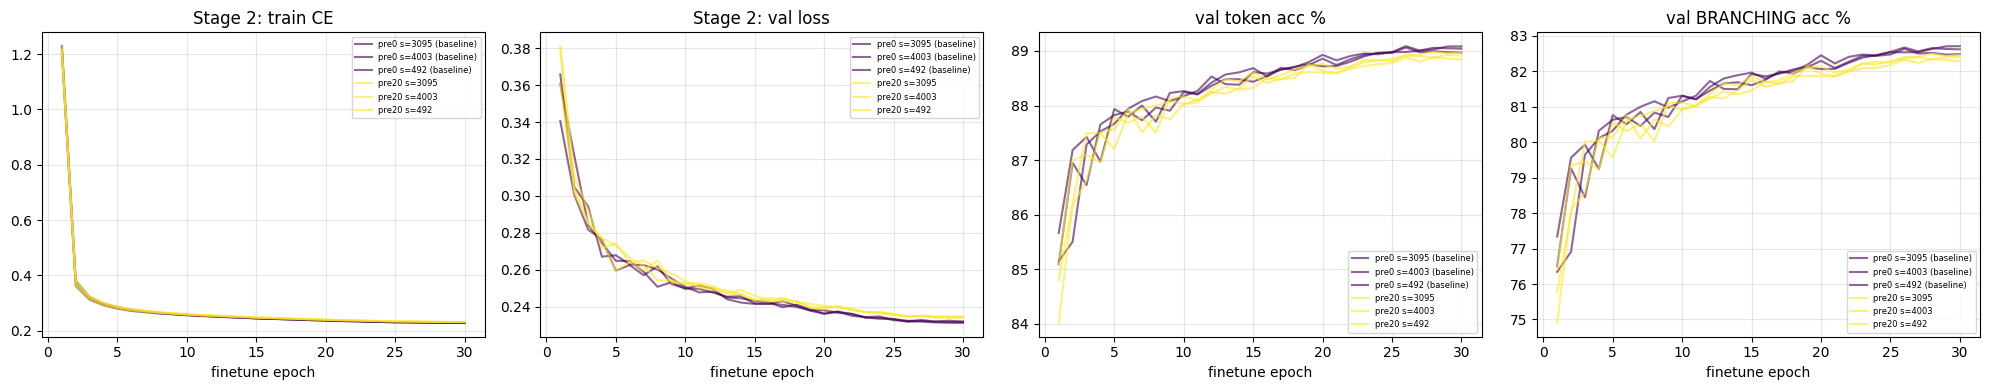

In [ ]:
import matplotlib.pyplot as plt


def load_history(pretrain_epochs, seed, data_seed=None):
    p = run_paths(pretrain_epochs, seed, data_seed)['history']
    if not p.exists():
        return None
    with open(p) as f:
        return json.load(f)


_fig, _ax = plt.subplots(1, 4, figsize=(20, 4))
_cmap = plt.get_cmap('viridis')
_col = {p: _cmap(i / max(len(PRETRAIN_EPOCHS_VALUES) - 1, 1))
        for i, p in enumerate(PRETRAIN_EPOCHS_VALUES)}

for _p in PRETRAIN_EPOCHS_VALUES:
    for _s in SEEDS:
        _h = load_history(_p, _s)
        if not _h:
            continue
        _lbl = f'pre{_p} s={_s}' + (' (baseline)' if _p == 0 else '')
        for _i, _key, _scale in ((0, 'train', 1), (1, 'val', 1),
                                 (2, 'val_acc', 100), (3, 'val_branch_acc', 100)):
            _series = _h.get(_key) or []
            if _series:
                _ax[_i].plot(range(1, len(_series) + 1),
                             [v * _scale for v in _series],
                             color=_col[_p], alpha=.6, label=_lbl)

for _i, _title in enumerate(['Stage 2: train CE', 'Stage 2: val loss',
                             'val token acc %', 'val BRANCHING acc %']):
    _ax[_i].set_title(_title)
    _ax[_i].set_xlabel('finetune epoch')
    _ax[_i].grid(alpha=.3)
    _ax[_i].legend(fontsize=6)
plt.tight_layout()
plt.show()

In [ ]:
%load_ext tensorboard
%tensorboard --logdir {LOCAL_LOG_ROOT}

<IPython.core.display.Javascript object>

### Inspect predictions

In [ ]:
def to_infix(prefix_str):
    """Prefix string -> infix via SymPy. Returns (infix_str, error_msg)."""
    try:
        expr, _ = prefix_to_sympy(prefix_str)
        return str(expr), None
    except Exception as e:
        return None, str(e)


def inspect_run(pretrain_epochs, seed, n_show=10, data_seed=None):
    """Show per-equation predictions from a run's metrics.json."""
    p = run_paths(pretrain_epochs, seed, data_seed)['metrics']
    if not p.exists():
        print(f'pretrain_{pretrain_epochs}/seed_{seed}: no metrics.json')
        return
    with open(p) as f:
        metrics = json.load(f)

    print(f'\n{"=" * 80}')
    print(f'pretrain_{pretrain_epochs}/seed_{seed} | '
          f'exact={metrics["greedy_exact_match"] * 100:.1f}% | '
          f'equiv={metrics["greedy_algebraic_equiv"] * 100:.1f}% | '
          f'val_branch_acc={metrics["best_val_branch_acc"] * 100:.1f}%')
    print(f'{"=" * 80}')

    details = metrics.get('details', [])
    for i, d in enumerate(details[:n_show]):
        gt_infix, _ = to_infix(d['gt'])
        pred_infix, pred_err = to_infix(d['pred'])
        r2 = f'{d["r2"]:.4f}' if d['r2'] is not None else 'N/A'
        status = ('EXACT' if d['exact'] else 'EQUIV' if d.get('equiv')
                  else 'PARSEABLE' if d.get('parseable') else 'UNPARSEABLE')
        print(f'\n── [{i}] {status} | R²={r2} ──')
        print(f'  GT:   {gt_infix}')
        if pred_err is None:
            print(f'  Pred: {pred_infix}')
        else:
            print(f'  Pred: PARSE FAILED ({pred_err})')
            print(f'        {d["pred"]}')

    print(f'\n  Total {len(details)} | '
          f'exact {sum(d["exact"] for d in details)} | '
          f'equiv {sum(1 for d in details if d.get("equiv"))} | '
          f'unparseable {sum(1 for d in details if not d.get("parseable", True))}')


for _p in PRETRAIN_EPOCHS_VALUES:
    inspect_run(_p, SEEDS[0], n_show=10)


pretrain_0/seed_3095 | exact=0.0% | equiv=35.9% | val_branch_acc=82.6%

── [0] EQUIV | R²=1.0000 ──
  GT:   c_0*(c_1 + c_2*x1)*exp(c_3*(c_4 + x1)**2)
  Pred: c_0*(c_7 + c_8*x1**2 + c_9*x1)*exp(c_10*(c_11 + x1)**2)/(c_1 + (c_2 + c_3*x1**3 + c_4*x1**4 + c_5*x1**2 + c_6*x1)**2)

── [1] EQUIV | R²=1.0000 ──
  GT:   c_0 + c_1*x1 + c_2*x1**3 + c_3*x1**2 + c_4*(c_8 + c_9*x1)/(c_5 + (c_6 + c_7*x1)**2)
  Pred: c_0 + c_1*x1**2 + c_2*x1 + c_3*x1**3 + c_4*sin(c_7 + c_8*x1)/(c_5 + c_6*x1**2) + c_9*cos(c_12 + c_13*x1)/(c_10 + c_11*x1**2)

── [2] PARSEABLE | R²=N/A ──
  GT:   c_0*sqrt(c_1 + (c_2 + c_3*x1**2 + c_4*x1**4 + c_5*x1 + c_6*x1**3)**2)*cos(c_7 + c_8*x1)**3
  Pred: c_0*sqrt(c_1 + (c_2 + c_3*x1**3 + c_4*x1**2 + c_5*x1 + c_6*x1**4)**2)*sin(c_7 + 4*x1)

── [3] EQUIV | R²=1.0000 ──
  GT:   c_0*exp(c_1*x1**2)*sinh(c_2*x1)
  Pred: c_0*exp(c_1*(c_2 + x1)**2) + c_3*exp(c_4*x1**2)*sinh(c_5*x1) + c_6*sin(c_10*x1 + c_9)/(c_7 + c_8*x1**2)

── [4] EQUIV | R²=0.9991 ──
  GT:   c_0*(c_5 + c_6*x1 + c_7*x1**

## 12. Does JEPA solve a SUPERSET of the baseline, or a different set?

This is a **secondary** analysis: it pools examples across seeds, whereas
the
section above pairs by model seed, which is the unit of replication for a
training procedure. Read it for the *shape* of the difference, not as a
significance test that overrides the seed-level result.

The aggregate gap cannot tell these apart. Two arms a few tenths apart are
consistent with

* **nested** — pretraining solves everything the baseline solves plus ~25
  more. A clean capability gain.
* **rotated** — the two arms solve substantially different sets of similar
  size, and +0.7 pp is the small residue of a much larger churn. Then the
  headline understates the run-to-run variance and the paired mean is a
  misleading summary.

Only the **discordant** examples carry information about which arm is
better, which is exactly McNemar's test. This reads the per-example
`details` already stored in every `metrics.json` — nothing is re-run.

`churn` is the number of examples that changed answer per unit of net gain.
1.0 is a pure addition; 5.0 means five examples moved to gain one.

In [ ]:
# `subdir` because runs live under model_<m>_data_<d>, not seed_<s>.
_DS = DATA_SEEDS[0]
_matrix = load_run_matrix(
    LOCAL_CHECKPOINT_ROOT, PRETRAIN_EPOCHS_VALUES, MODEL_SEEDS,
    subdir=lambda m: run_dirname(m, _DS))

AGREEMENT = {}
for _metric in ('equiv', 'r2>0.9', 'exact'):
    _lo, _hi = min(PRETRAIN_EPOCHS_VALUES), max(PRETRAIN_EPOCHS_VALUES)
    if not (_matrix.get(_lo) and _matrix.get(_hi)):
        print(f'skipping {_metric}: need both arms evaluated')
        continue
    AGREEMENT[_metric] = compare_runs(
        _matrix[_lo], _matrix[_hi], metric=_metric,
        name_a=f'pretrain_{_lo}', name_b=f'pretrain_{_hi}')
    print('\n' + '=' * 78 + '\n')

=== equiv: pretrain_0 vs pretrain_20 over 3 seeds ===

    seed    both   only_a   only_b    net   nested         p
     492    1038      173      144    -29    False     0.116
    3095    1050      159      141    -18    False     0.326
    4003    1038      172      169     -3    False     0.914

pretrain_20 wins the discordant count in 0/3 seeds; nested in 0/3

POOLED
equiv: pretrain_0 3630/10113 (35.89%) vs pretrain_20 3580/10113 (35.40%)
  both correct        : 3126
  only pretrain_0    : 504
  only pretrain_20   : 454
  neither             : 6029
  net                 : -50
  discordant          : 958 (9.47% of the test set)
  McNemar exact p     : 0.1133
  -> NOT nested: pretrain_20 lost 504 that pretrain_0 solved. Churn = 19.2x the net gain, so the arms differ on 958 examples to move -50.


=== r2>0.9: pretrain_0 vs pretrain_20 over 3 seeds ===

    seed    both   only_a   only_b    net   nested         p
     492    2291      165      169     +4    False      0.87
    3095    

### Where do the gains sit?

A gain concentrated on short expressions means something different from one
spread evenly.

In [ ]:
from symbolic_jepa.agreement import stratified_agreement  # noqa: E402

_lo, _hi = min(PRETRAIN_EPOCHS_VALUES), max(PRETRAIN_EPOCHS_VALUES)
if _matrix.get(_lo) and _matrix.get(_hi):
    _shared = sorted(set(_matrix[_lo]) & set(_matrix[_hi]))
    _rows = {}
    for _s in _shared:
        for _band, _v in stratified_agreement(
                _matrix[_lo][_s], _matrix[_hi][_s], metric='equiv').items():
            _acc = _rows.setdefault(_band, {k: 0 for k in _v})
            for _k, _n in _v.items():
                _acc[_k] += _n
    print(f'{"gt tokens":>12}{"n":>8}{"base":>8}{"jepa":>8}'
          f'{"only_base":>11}{"only_jepa":>11}{"net":>7}')
    for _band, _v in _rows.items():
        print(f'{_band:>12}{_v["n"]:>8}{_v["a_correct"]:>8}{_v["b_correct"]:>8}'
              f'{_v["only_a"]:>11}{_v["only_b"]:>11}'
              f'{_v["only_b"] - _v["only_a"]:>+7d}')

   gt tokens       n    base    jepa  only_base  only_jepa    net
        0-10      18      11      12          1          2     +1
       10-20     273      73      83          7         17    +10
       20-30     924     252     266         37         51    +14
      30-100    8898    3294    3219        459        384    -75


## 13. Does the advantage grow, shrink, or appear late?

`SYMBOLIC_EVAL_EVERY` records `equiv` and `R2>0.9` on a fixed validation
prefix during training. A gap present from epoch 5 means something different
from one that only opens up late.

                   run  sym points  val epochs
  pretrain_0/seed_3095           6          30
  pretrain_0/seed_4003           6          30
   pretrain_0/seed_492           6          30
 pretrain_20/seed_3095           6          30
 pretrain_20/seed_4003           6          30
  pretrain_20/seed_492           6          30

6 run(s) have symbolic data, 0 do not; 0 of those are a backfilled ENDPOINT only.


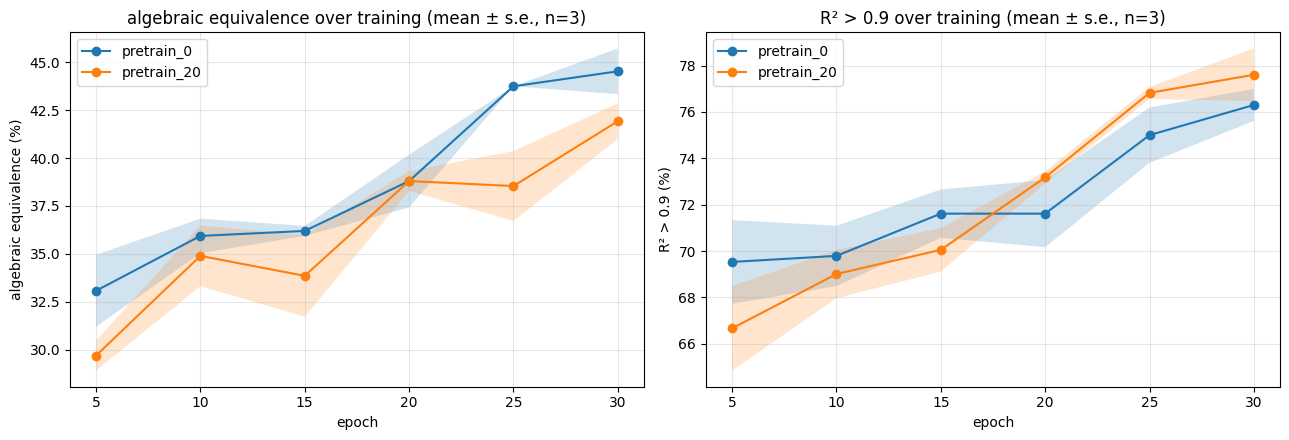

In [ ]:
# Which runs actually recorded a trajectory. A run trained before
# SYMBOLIC_EVAL_EVERY existed, or resumed already-complete, has none — and it
# cannot be backfilled from a final checkpoint.
print(f'{"run":>22}{"sym points":>12}{"val epochs":>12}')
_n_with = _n_without = 0
for _p in PRETRAIN_EPOCHS_VALUES:
    for _s in SEEDS:
        _h = load_history(_p, _s) or {}
        _k = len(_h.get('sym_equiv', []))
        _n_with += bool(_k)
        _n_without += (not _k)
        print(f'{f"pretrain_{_p}/seed_{_s}":>22}{_k:>12}'
              f'{len(_h.get("val", [])):>12}')
_n_backfilled = sum(
    bool((load_history(_p, _s) or {}).get('sym_backfilled'))
    for _p in PRETRAIN_EPOCHS_VALUES for _s in SEEDS)
print(f'\n{_n_with} run(s) have symbolic data, {_n_without} do not; '
      f'{_n_backfilled} of those are a backfilled ENDPOINT only.')
if _n_backfilled:
    print('A backfilled run contributes one point at its final epoch — enough '
          'to compare arms end-to-end, but not a trajectory. Retrain it to get '
          'the curve; the per-epoch values cannot be recovered from its final '
          'weights.')

_have_sym = any('sym_equiv' in (load_history(_p, _s) or {})
                for _p in PRETRAIN_EPOCHS_VALUES for _s in SEEDS)

if not _have_sym:
    print('No mid-training symbolic history found — this needs a run with '
          'SYMBOLIC_EVAL_EVERY > 0.')
else:
    _fig, _axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for _ax, _key, _label in ((_axes[0], 'sym_equiv', 'algebraic equivalence'),
                              (_axes[1], 'sym_r2_above_0.9', 'R² > 0.9')):
        for _p in PRETRAIN_EPOCHS_VALUES:
            _curves = []
            _ep = None
            for _s in SEEDS:
                _h = load_history(_p, _s)
                if not _h or _key not in _h:
                    continue
                _curves.append(_h[_key])
                _ep = _h.get('sym_epoch')
            if not _curves:
                continue
            _n = min(len(c) for c in _curves)
            _arr = np.array([c[:_n] for c in _curves])
            _mean = _arr.mean(axis=0) * 100
            _se = _arr.std(axis=0, ddof=1) / np.sqrt(len(_arr)) * 100 \
                if len(_arr) > 1 else np.zeros(_n)
            _x = (_ep or list(range(1, _n + 1)))[:_n]
            _ax.plot(_x, _mean, marker='o', label=f'pretrain_{_p}')
            _ax.fill_between(_x, _mean - _se, _mean + _se, alpha=0.2)
        _ax.set_xlabel('epoch')
        _ax.set_ylabel(f'{_label} (%)')
        _ax.set_title(f'{_label} over training (mean ± s.e., n={len(SEEDS)})')
        _ax.legend()
        _ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()